# ATP Japan — Data Preparation


**Foi efetuada a importação do ficheiro atpplayers.json para a base de dados atpplayers no software MongoDB, com a criação de uma coleção denominada**
**por players. Após a importação, verificou-se que o nosso dataset contém 1308835 observações e procedeu-se à exportação das observações para** 
**formato .csv que irá ser utilizado no software python, para análise das mesmas.**

# **Importação de todas as bibliotecas necessárias**

In [1]:
import pandas as pd
import numpy as np
import openpyxl
import unicodedata
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# **Importação da base de dados** 

In [2]:
# Importar a base de dados ATP
df = pd.read_csv('atp_db.csv')

# **Análise exploratória de dados**

### **Estrutura da base de dados**

In [3]:
# Ver as primeiras linhas
print(df.head())

                                  _id      PlayerName              Born  \
0  ObjectId(624ab34913b144c54b3c9abe)  Novak Djokovic  Belgrade, Serbia   
1  ObjectId(624ab34913b144c54b3c9abc)  Novak Djokovic  Belgrade, Serbia   
2  ObjectId(624ab34913b144c54b3c9ac2)  Novak Djokovic  Belgrade, Serbia   
3  ObjectId(624ab34913b144c54b3c9aba)  Novak Djokovic  Belgrade, Serbia   
4  ObjectId(624ab34913b144c54b3c9ac3)  Novak Djokovic  Belgrade, Serbia   

   Height                               Hand  \
0   188.0  Right-Handed, Two-Handed Backhand   
1   188.0  Right-Handed, Two-Handed Backhand   
2   188.0  Right-Handed, Two-Handed Backhand   
3   188.0  Right-Handed, Two-Handed Backhand   
4   188.0  Right-Handed, Two-Handed Backhand   

                                          LinkPlayer              Tournament  \
0  https://www.atptour.com/en/players/novak-djoko...  ATP Masters 1000 Paris   
1  https://www.atptour.com/en/players/novak-djoko...        Nitto ATP Finals   
2  https://www.atpto

In [4]:
# Número de observações e variáveis do conjunto de dados
print(df.shape)

(1308835, 16)


In [5]:
# Nome das variáveis
print(df.columns)
print(df.info())

Index(['_id', 'PlayerName', 'Born', 'Height', 'Hand', 'LinkPlayer',
       'Tournament', 'Location', 'Date', 'Ground', 'Prize', 'GameRound',
       'GameRank', 'Oponent', 'WL', 'Score'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1308835 entries, 0 to 1308834
Data columns (total 16 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   _id         1308835 non-null  object 
 1   PlayerName  1308835 non-null  object 
 2   Born        988083 non-null   object 
 3   Height      982658 non-null   float64
 4   Hand        1116918 non-null  object 
 5   LinkPlayer  1308835 non-null  object 
 6   Tournament  1308835 non-null  object 
 7   Location    1308835 non-null  object 
 8   Date        1308835 non-null  object 
 9   Ground      1308644 non-null  object 
 10  Prize       1289699 non-null  object 
 11  GameRound   1308835 non-null  object 
 12  GameRank    1289599 non-null  object 
 13  Oponent     1308828 non-null

In [6]:
# Verificar valores nulos e omissos
print(df.isna().sum())

_id                0
PlayerName         0
Born          320752
Height        326177
Hand          191917
LinkPlayer         0
Tournament         0
Location           0
Date               0
Ground           191
Prize          19136
GameRound          0
GameRank       19236
Oponent            7
WL             19257
Score          19400
dtype: int64


### **Seleção da amostra do Dataset de acordo com a localização do torneio - Japão**

Foi extraída a lista de localizações dos torneios únicas presentes na variável Location da base de dados. Posteriormente, essa lista de 2512 observações foi convertida para um DataFrame e exportada para um ficheiro Excel, com o objetivo de facilitar a análise e a verificação das localizações correspondentes ao país Japão.

In [7]:
# Obter localizações únicas
localizacoes_unicas = df["Location"].unique()

# Contar o número de localizações únicas
print(f"Número de localizações únicas: {len(localizacoes_unicas)}")

# Converter para DataFrame
df_localizacoes = pd.DataFrame(localizacoes_unicas, columns=["Location"])

# Guardar em ficheiro Excel
df_localizacoes.to_excel("ANALYZE_unique_locations.xlsx", index=False)

Número de localizações únicas: 2512


Após a análise das localizações únicas no Excel, confirmou-se que todas as entradas relativas ao Japão contêm a palavra "Japan". Procedeu-se, assim, à seleção da amostra através da filtragem por essa palavra. De seguida, compilou-se as linhas que compõem o subconjunto de dados referente ao país Japão.

In [8]:
# Filtragem das linhas que compõem o subconjunto de dados onde a variável "Location" contém a designação "Japan"
df_japan = df[df['Location'].str.contains("Japan", case=False, na=False)].copy()

Contabilização do número de linhas e variáveis do subconjunto de dados Japão e listagem do nome das colunas.

In [9]:
# Número de observaçoes e variáveis do subconjunto de dados
print(df_japan.shape)
# Nome das variáveis
print(df_japan.columns)

(21375, 16)
Index(['_id', 'PlayerName', 'Born', 'Height', 'Hand', 'LinkPlayer',
       'Tournament', 'Location', 'Date', 'Ground', 'Prize', 'GameRound',
       'GameRank', 'Oponent', 'WL', 'Score'],
      dtype='object')


In [10]:
# Verificar valores nulos e omissos
print(df_japan.isna().sum())

_id              0
PlayerName       0
Born          6300
Height        6349
Hand          2884
LinkPlayer       0
Tournament       0
Location         0
Date             0
Ground           0
Prize          421
GameRound        0
GameRank       424
Oponent          0
WL             424
Score          424
dtype: int64


In [11]:
# Visualização das primeiras linhas do subconjunto de dados
df_japan.head()

,_id,PlayerName,Born,Height,Hand,LinkPlayer,Tournament,Location,Date,Ground,Prize,GameRound,GameRank,Oponent,WL,Score
14,ObjectId(624ab34913b144c54b3c9acd),Novak Djokovic,"Belgrade, Serbia",188.0,"Right-Handed, Two-Handed Backhand",https://www.atptour.com/en/players/novak-djoko...,Tokyo Olympics,"Tokyo, Japan",2021.07.26 - 2021.08.01,Hard,NaN,Semi-Finals,5,Alexander Zverev,L,61 36 16
24,ObjectId(624ab34913b144c54b3c9acc),Novak Djokovic,"Belgrade, Serbia",188.0,"Right-Handed, Two-Handed Backhand",https://www.atptour.com/en/players/novak-djoko...,Tokyo Olympics,"Tokyo, Japan",2021.07.26 - 2021.08.01,Hard,NaN,Olympic Bronze,11,Pablo Carreno Busta,L,"46 76, 36"
26,ObjectId(624ab34913b144c54b3c9ad4),Novak Djokovic,"Belgrade, Serbia",188.0,"Right-Handed, Two-Handed Backhand",https://www.atptour.com/en/players/novak-djoko...,Tokyo Olympics,"Tokyo, Japan",2021.07.26 - 2021.08.01,Hard,NaN,Quarter-Finals,69,Kei Nishikori,W,62 60
27,ObjectId(624ab34913b144c54b3c9ad5),Novak Djokovic,"Belgrade, Serbia",188.0,"Right-Handed, Two-Handed Backhand",https://www.atptour.com/en/players/novak-djoko...,Tokyo Olympics,"Tokyo, Japan",2021.07.26 - 2021.08.01,Hard,NaN,Round of 16,34,Alejandro Davidovich Fokina,W,63 61
28,ObjectId(624ab34913b144c54b3c9ad6),Novak Djokovic,"Belgrade, Serbia",188.0,"Right-Handed, Two-Handed Backhand",https://www.atptour.com/en/players/novak-djoko...,Tokyo Olympics,"Tokyo, Japan",2021.07.26 - 2021.08.01,Hard,NaN,Round of 32,48,Jan-Lennard Struff,W,64 63


# **Preparação de dados**

### **Criação do campo BornCountry apenas com o país de nascimento**

Como o campo Born, que indica o país de naturalidade do jogador, apresentava diferentes formatos (por exemplo, "Cidade, País" ou "Cidade, Estado, País"), foi criada uma nova variável denominada BornCountry, que extrai apenas o país, considerando o último elemento após a separação por vírgulas. Após a criação da variável BornCountry é eliminada a coluna Born.

In [12]:
# Extrair apenas o país da variável 'Born', criando uma nova variável 'BornCountry'
df_japan['BornCountry'] = df_japan['Born'].str.split(',').str[-1].str.strip()

# Remover a coluna original 'Born'
df_japan.drop(columns=['Born'], inplace=True)

# Visualizar os primeiros registos
df_japan.head()

,_id,PlayerName,Height,Hand,LinkPlayer,Tournament,Location,Date,Ground,Prize,GameRound,GameRank,Oponent,WL,Score,BornCountry
14,ObjectId(624ab34913b144c54b3c9acd),Novak Djokovic,188.0,"Right-Handed, Two-Handed Backhand",https://www.atptour.com/en/players/novak-djoko...,Tokyo Olympics,"Tokyo, Japan",2021.07.26 - 2021.08.01,Hard,NaN,Semi-Finals,5,Alexander Zverev,L,61 36 16,Serbia
24,ObjectId(624ab34913b144c54b3c9acc),Novak Djokovic,188.0,"Right-Handed, Two-Handed Backhand",https://www.atptour.com/en/players/novak-djoko...,Tokyo Olympics,"Tokyo, Japan",2021.07.26 - 2021.08.01,Hard,NaN,Olympic Bronze,11,Pablo Carreno Busta,L,"46 76, 36",Serbia
26,ObjectId(624ab34913b144c54b3c9ad4),Novak Djokovic,188.0,"Right-Handed, Two-Handed Backhand",https://www.atptour.com/en/players/novak-djoko...,Tokyo Olympics,"Tokyo, Japan",2021.07.26 - 2021.08.01,Hard,NaN,Quarter-Finals,69,Kei Nishikori,W,62 60,Serbia
27,ObjectId(624ab34913b144c54b3c9ad5),Novak Djokovic,188.0,"Right-Handed, Two-Handed Backhand",https://www.atptour.com/en/players/novak-djoko...,Tokyo Olympics,"Tokyo, Japan",2021.07.26 - 2021.08.01,Hard,NaN,Round of 16,34,Alejandro Davidovich Fokina,W,63 61,Serbia
28,ObjectId(624ab34913b144c54b3c9ad6),Novak Djokovic,188.0,"Right-Handed, Two-Handed Backhand",https://www.atptour.com/en/players/novak-djoko...,Tokyo Olympics,"Tokyo, Japan",2021.07.26 - 2021.08.01,Hard,NaN,Round of 32,48,Jan-Lennard Struff,W,64 63,Serbia


Para verificar a estrutura do novo campo `BornCountry` da nossa amostra, analisámos os valores nulos e únicos da variável. Verificámos que existem 6300 observações por preencher.

In [13]:
# Número de valores nulos na variável "Born"
print(f"Número de valores nulos na variável 'BornCountry': {df_japan['BornCountry'].isna().sum()}")
# Valores únicos na variável "BornCountry"
print(f"Valores únicos na variável 'BornCountry': {df_japan['BornCountry'].unique()}")

Número de valores nulos na variável 'BornCountry': 6300
Valores únicos na variável 'BornCountry': ['Serbia' 'Russia' 'Spain' 'Germany' 'Greece' 'Canada' 'Poland' 'USA'
 'Israel' 'Argentina' 'Georgia' 'Italy' 'Bosnia-Herzegovina' 'France'
 'Switzerland' 'England' 'Australia' 'Bulgaria' 'Belarus' 'South Africa'
 'Austria' 'Japan' 'South Korea' 'Belgium' 'Finland' 'Czech Republic'
 'Portugal' 'Ukraine' 'Lithuania' 'Bolivia' 'Slovakia' 'Brazil' 'Moldova'
 'Colombia' 'Peru' 'Chile' 'Ecuador' 'Chinese Taipei' 'Croatia' 'India'
 'Montenegro' 'The Netherlands' 'Mauritius' 'Slovenia' 'Turkey' 'Romania'
 'Netherlands' nan 'Geneva' 'Sydney' 'Latvia' 'Tunisia' 'Changhwa' 'Egypt'
 'Monaco' 'Box Hill' 'China' 'CA' 'Vietnam' 'Paris' 'Gangwonto' 'Taiwan'
 'Dirksland' 'Uzbekistan' 'Great Britain' 'Melbourne'
 'Bosnia & Herzegovina' 'Taipei' 'Tokyo' 'Zimbabwe' 'Osaka Japan'
 'Tianjin' 'Shizuoka' 'Fukushima' 'New Zealand' 'Ishikawa' 'Osaka'
 'Okayama' 'Korea' 'Yamagata' 'keelung' 'Sweden' 'Andong' 'Spoka

Após a análise dos valores únicos no campo `BornCountry`, verificámos a presença de muitos valores que não correspondem a países válidos. Para resolver esta situação, iremos atualizar a informação de país de nascimento de todos os jogadores, recorrendo a uma base de dados externa que contém informação sobre aproximadamente 65000 jogadores. Dado que muitos nomes se encontram no formato invertido (Apelido Nome), esta particularidade foi devidamente considerada no processo.

### **Transformação da base de dados externa `EXTERNAL_players` - Criação do campo `Name`**

Importação da base de dados externa `EXTERNAL_players.csv`, adquirida no Kaggle, com aproximadamente 65000 registos de jogadores de ténis.

In [14]:
# Importar a base de dados externa com os países de nascimento dos jogadores
external_df = pd.read_csv('EXTERNAL_players.csv', delimiter=",")  # Base externa com nomes corretos e países
# Juntar as duas colunas name_first e name_last para criar a coluna 'Name'
external_df['Name'] = external_df['name_first'] + ' ' + external_df['name_last']
# Ver as primeiras linhas
print(external_df.head())

   player_id name_first name_last hand         dob  ioc  height wikidata_id  \
0     100001    Gardnar    Mulloy    R  19131122.0  USA   185.0      Q54544   
1     100002     Pancho    Segura    R  19210620.0  ECU   168.0      Q54581   
2     100003      Frank   Sedgman    R  19271002.0  AUS   180.0     Q962049   
3     100004   Giuseppe     Merlo    R  19271011.0  ITA     NaN    Q1258752   
4     100005    Richard  Gonzalez    R  19280509.0  USA   188.0      Q53554   

               Name  
0    Gardnar Mulloy  
1     Pancho Segura  
2     Frank Sedgman  
3    Giuseppe Merlo  
4  Richard Gonzalez  


Após importação foi criada a coluna ``Name`` na base de dados externa, concatenando as colunas ``name_first`` e ``name_last``, de modo a existir um campo com o nome completo dos jogadores.  
Com isto, originou-se um novo documento, designado por `EXTERNAL_players_fullname.csv`.

In [15]:
# Ver as primeiras linhas
print(external_df.head())
# Guardar a base de dados modificada
external_df.to_csv('EXTERNAL_players_fullname.csv',sep=';', index=False)

   player_id name_first name_last hand         dob  ioc  height wikidata_id  \
0     100001    Gardnar    Mulloy    R  19131122.0  USA   185.0      Q54544   
1     100002     Pancho    Segura    R  19210620.0  ECU   168.0      Q54581   
2     100003      Frank   Sedgman    R  19271002.0  AUS   180.0     Q962049   
3     100004   Giuseppe     Merlo    R  19271011.0  ITA     NaN    Q1258752   
4     100005    Richard  Gonzalez    R  19280509.0  USA   188.0      Q53554   

               Name  
0    Gardnar Mulloy  
1     Pancho Segura  
2     Frank Sedgman  
3    Giuseppe Merlo  
4  Richard Gonzalez  


### **Atualização dos países dos jogadores na variável `BornCountry` e dos nomes dos jogadores `PlayerName`**

Com a base de dados externa pronta, os próximos passos foram:

**1- Atualização do país de acordo com o nome do jogador:** - Indentificámos o país de cada jogador através da correspondência do nome com a base de dados externa. Sempre que o nome é encontrado, o país associado é atualizado na coluna `BornCountry`.

**2- Substituição do nome do jogador:** - Foi criada a coluna `PlayerNameCorrected`, que contém os nomes corrigidos com referência à base de dados externa (com acentos corretos, hífens e apóstrofos e com a ordem dos nomes ajustada). A correspondência dos nomes foi feita de forma direta ou invertida para garantir que o nome correto fosse atribuído.

**3- Remoção da coluna auxiliar:** - A coluna `PlayerNameCorrected` foi removida após a sua informação ter sido incorporada na coluna principal `PlayerName`. Após isso, a coluna `PlayerName` contém os nomes finais corrigidos.

**4- Atualização dos países:** - A coluna `BornCountry` foi atualizada com os países corretos provenientes da base de dados externa, conforme os nomes dos jogadores.

In [16]:
def normalize_text(text):
    """Normaliza texto removendo acentos, hífens, apóstrofos e padronizando espaços"""
    if pd.isna(text):
        return None
    text = str(text)
    text = (unicodedata.normalize('NFKD', text)
            .encode('ASCII', 'ignore')
            .decode('ASCII')
            .replace("-", " ")
            .replace("'", " ")
            .lower())
    return ' '.join(text.split())

# Pré-processamento da base de externa com o nome normalizado
external_df['normalized_name'] = external_df['Name'].apply(normalize_text)

def find_country_and_correct_name(player_name, external_df):
    """Encontra o país e o nome correto do jogador"""
    if pd.isna(player_name):
        return None, player_name  # Mantém o nome original

    normalized_name = normalize_text(player_name)

    # Correspondência direta
    match = external_df[external_df['normalized_name'] == normalized_name]
    if not match.empty:
        return match.iloc[0]['ioc'], match.iloc[0]['Name']

    # Nome invertido 
    partes = normalized_name.split()
    if len(partes) == 2:
        inverted_name = ' '.join(reversed(partes))
        match = external_df[external_df['normalized_name'] == inverted_name]
        if not match.empty:
            return match.iloc[0]['ioc'], match.iloc[0]['Name']

    # Sem correspondência direta
    """Mantém o nome original e retorna None para o país"""
    return None, player_name

# Aplicar ao dataframe df_japan
df_japan[['BornCountry', 'PlayerNameCorrected']] = df_japan['PlayerName'].apply(
    lambda name: pd.Series(find_country_and_correct_name(name, external_df))
)

# Substituir 'PlayerName' pela versão corrigida
df_japan['PlayerName'] = df_japan['PlayerNameCorrected']

# Remover a coluna auxiliar
df_japan.drop(columns=['PlayerNameCorrected'], inplace=True)

print("Processo concluído com sucesso!")

# Atualizar a base de dados original com os nomes corrigidos
df_japan.to_excel('df_japan.xlsx', index=False)
print("Base de dados atualizada com sucesso!")


Processo concluído com sucesso!
Base de dados atualizada com sucesso!


In [17]:
df_japan['GameRound'].unique()


array(['Semi-Finals', 'Olympic Bronze', 'Quarter-Finals', 'Round of 16',
       'Round of 32', 'Round of 64', 'Finals', '1st Round Qualifying',
       '2nd Round Qualifying', 'Round Robin', '3rd Round Qualifying'],
      dtype=object)

Após a atualização, foi realizada uma verificação dos valores presentes na coluna `BornCountry`.

In [18]:
# Valores únicos na variável "BornCountry" após a atualização
print(f"Valores únicos na variável 'BornCountry' após a atualização: {df_japan['BornCountry'].unique()}")

Valores únicos na variável 'BornCountry' após a atualização: ['SRB' 'RUS' 'ESP' 'GER' 'GRE' 'CAN' 'POL' 'USA' 'ARG' 'GEO' 'ITA' 'CRO'
 'FRA' 'SUI' 'GBR' 'AUS' 'BUL' 'KAZ' None 'BLR' 'RSA' 'AUT' 'JPN' 'BEL'
 'FIN' 'CZE' 'POR' 'LTU' 'BOL' 'URU' 'SVK' 'BRA' 'MDA' 'COL' 'PER' 'BIH'
 'CHI' 'ECU' 'TPE' 'IND' 'NED' 'SLO' 'TUR' 'UKR' 'ROU' 'UZB' 'LAT' 'TUN'
 'KOR' 'ISR' 'EGY' 'MON' 'CHN' 'VIE' 'ZIM' 'THA' 'SWE' 'PAK' 'LUX' 'IRL'
 'INA' 'DEN' 'PHI' 'NZL' 'MAS' 'MNE' 'PAR' 'VEN' 'MAR' 'NAM' 'HKG' 'ARM'
 'MEX' 'AZE' 'PUR' 'BAH' 'NOR' 'HAI' 'NGR' 'KEN' 'YUG' 'SGP']


 Ao analisar os valores únicos do campo `BornCountry`, verificou-se que ainda existiam vários registos com o valor `None`, o que indica que não foi possível identificar o país para esses jogadores com base na base de dados externa.

In [19]:
# Valores nulos na variável "BornCountry" após a atualização
print(f"Número de valores nulos na variável 'BornCountry' após a atualização: {df_japan['BornCountry'].isna().sum()}")

Número de valores nulos na variável 'BornCountry' após a atualização: 317


Após a atualização dos registos com base no ficheiro externo EXTERNAL_Players.csv, foi possível preencher automaticamente a maioria dos valores na variável BornCountry, correspondente ao país de nascimento dos jogadores. 
No entanto, verificou-se que permanecem por preencher 317 registos. Na qual, confirmámos os jogadores em que o campo BornCountry, não estava preenchido.

In [20]:
# Ver os jogadores únicos que não têm país de nascimento
players_without_born = df_japan[df_japan['BornCountry'].isnull()]['PlayerName'].unique()
print(f"Jogadores sem país de nascimento: {players_without_born}")
# Verificar o número de jogadores únicos sem país de nascimento
print(f"\nNúmero de jogadores únicos sem país de nascimento: {len(players_without_born)}")

Jogadores sem país de nascimento: ['Albert Ramos-Vinolas' 'Soonwoo Kwon' "Christopher O'Connell"
 'Mukund Sasikumar' 'Duckhee Lee' 'Rubin Statham' 'N.Sriram Balaji'
 'MinKyu Song' 'Sanhui Shin' 'Mikal Statham' 'Pol Wattanakul'
 'Anton Zaitcev' 'Min-Hyeok Cho' 'Alex Bogomolov Jr.' 'Sun-Yong Kim Jr.'
 'Treat Huey' "Massimo Dell'Acqua" "Luigi D'Agord" 'G.D. Jones'
 'Oscar Burrieza-Lopez' 'Sky Kim' 'Yu Jr. Wang' 'Jamie Cerretani'
 'K.C. Corkery' 'Matt Scott' "Claude N'Goran" 'Yungu Park' "Alex O'Brien"
 'Yamato Dono' 'Hung-Soon Park' 'Niclas Kroon' 'Juan Gisbert Sr'
 'Alafia Ayeni' 'Dusty H. Boyer' 'Hong Kit Wong']

Número de jogadores únicos sem país de nascimento: 35


Dos jogadores analisados, identificámos 35 casos únicos sem correspondência automática. Para esses registos, realizámos uma pesquisa manual para determinar o seu nome correto e os seus países de nascimento. As informações pesquisadas foram organizadas num dicionário, que será utilizado para atualizar a nossa amostra.

In [21]:
# Criar um dicionário manual para corrigir os nomes dos jogadores
players_manual_fix = {
    'Albert Ramos-Vinolas': 'Albert Ramos-Viñolas',
    'Soonwoo Kwon': 'Kwon Soon-woo',
    'Mukund Sasikumar': 'Sasikumar Mukund',
    'Duckhee Lee': 'Lee Duck-hee',
    'MinKyu Song': 'Minkyu Song',
    'Anton Zaitcev': 'Anton Zaitsev',
    'Jamie Cerretani': 'James Cerretani'
}

# Dicionário completo com os países dos jogadores sem país de nascimento
players_manual_fill = {
    'Albert Ramos-Viñolas': 'ESP',
    'Kwon Soon-woo': 'KOR',
    "Christopher O'Connell": 'AUS',
    'Sasikumar Mukund': 'IND',
    'Lee Duck-hee': 'KOR',
    'Rubin Statham': 'NZL',
    'N.Sriram Balaji': 'IND',
    'Minkyu Song': 'KOR',
    'Sanhui Shin': 'KOR',
    'Mikal Statham': 'NZL',
    'Pol Wattanakul': 'THA',
    'Anton Zaitsev': 'RUS',
    'Min-Hyeok Cho': 'KOR',
    'Alex Bogomolov Jr.': 'RUS',
    'Sun-Yong Kim Jr.': 'KOR',
    'Treat Huey': 'PHL',
    "Massimo Dell'Acqua": 'ITA',
    "Luigi D'Agord": 'ITA',
    'G.D. Jones': 'NZL',
    'Oscar Burrieza-Lopez': 'ESP',
    'Sky Kim': 'USA',
    'Yu Jr. Wang': 'CHN',
    'James Cerretani': 'USA',
    'K.C. Corkery': 'USA',
    'Matt Scott': 'CAN',
    "Claude N'Goran": 'CIV',
    'Yungu Park': 'KOR',
    "Alex O'Brien": 'USA',
    'Yamato Dono': 'JPN',
    'Hung-Soon Park': 'KOR',
    'Niclas Kroon': 'SWE',
    'Juan Gisbert Sr': 'ESP',
    'Alafia Ayeni': 'USA',
    'Dusty H. Boyer': 'USA',
    'Hong Kit Wong': 'HKG'
}

# Corrigir nomes diretamente no PlayerName
df_japan['PlayerName'] = df_japan['PlayerName'].replace(players_manual_fix)
# Corrigir nomes diretamente no Opponent
df_japan['Oponent'] = df_japan['Oponent'].replace(players_manual_fix)

# Atualizar BornCountry para jogadores principais, com base nos nomes corrigidos
for player, country in players_manual_fill.items():
    mask = df_japan['PlayerName'] == player
    df_japan.loc[mask, 'BornCountry'] = country
    
# Guardar a base atualizada com o campo 'BornCountry' preenchido
#df_japan.to_excel('df_japan.xlsx', index=False)
#print("Base de dados atualizada com sucesso!")

In [22]:
# Verificar se todos foram preenchidos
missing_now = df_japan[df_japan['BornCountry'].isna()]['PlayerName'].unique()
print(f"Jogadores sem país após preenchimento manual: {len(missing_now)}")
# Valores únicos na variável "BornCountry" após preenchimento manual
print(f"\nValores únicos na variável 'BornCountry' após preenchimento manual: {df_japan['BornCountry'].unique()}")

Jogadores sem país após preenchimento manual: 0

Valores únicos na variável 'BornCountry' após preenchimento manual: ['SRB' 'RUS' 'ESP' 'GER' 'GRE' 'CAN' 'POL' 'USA' 'ARG' 'GEO' 'ITA' 'CRO'
 'FRA' 'SUI' 'GBR' 'AUS' 'BUL' 'KAZ' 'BLR' 'RSA' 'AUT' 'JPN' 'KOR' 'BEL'
 'FIN' 'CZE' 'POR' 'LTU' 'BOL' 'URU' 'SVK' 'BRA' 'MDA' 'COL' 'PER' 'BIH'
 'CHI' 'ECU' 'TPE' 'IND' 'NED' 'SLO' 'TUR' 'UKR' 'ROU' 'UZB' 'LAT' 'TUN'
 'ISR' 'EGY' 'MON' 'CHN' 'VIE' 'NZL' 'ZIM' 'THA' 'SWE' 'PAK' 'LUX' 'IRL'
 'INA' 'DEN' 'PHI' 'MAS' 'MNE' 'PHL' 'PAR' 'VEN' 'MAR' 'NAM' 'HKG' 'ARM'
 'MEX' 'AZE' 'PUR' 'CIV' 'BAH' 'NOR' 'HAI' 'NGR' 'KEN' 'YUG' 'SGP']


### **Criação das variáveis ``PlayerCountry`` e ``OpponentCountry`` a partir do BornCountry**

Para a criação das variáveis PlayerCountry e OpponentCountry foi criado um dicionário de correspondência entre PlayerName e BornCountry, permitindo associar a cada jogador o respetivo país.

In [23]:
# Criar dicionário de correspondência entre jogador e país
player_country_dict = df_japan.set_index('PlayerName')['BornCountry'].to_dict()

Utilizando este dicionário, orginou-se duas novas variáveis:

- PlayerCountry, que associa o país ao próprio jogador (PlayerName).

- OpponentCountry, que associa o país ao adversário (Opponent), **sempre que este já tenha aparecido como PlayerName no conjunto de dados.**

In [24]:
# Preencher a coluna PlayerCountry com base em PlayerName
df_japan['PlayerCountry'] = df_japan['PlayerName'].map(player_country_dict)

# Mudar o nome da coluna 'Oponent' para 'Opponent'
if 'Oponent' in df_japan.columns:
    df_japan.rename(columns={'Oponent': 'Opponent'}, inplace=True)

# 4. Preencher a coluna OpponentCountry com base no nome do Opponent, consultando o mesmo dicionário
df_japan['OpponentCountry'] = df_japan['Opponent'].map(player_country_dict)

Após o preenchimento dos países nas variáveis PlayerCountry e OpponentCountry, procedeu-se à verificação dos valores nulos. Confirmou-se a existência de jogadores adversários (Oponent) cuja nacionalidade não pôde ser atribuída automaticamente, por não existirem registos prévios desses nomes como PlayerName no conjunto de dados.

In [25]:
# Verificar o número de valores nulos nas colunas principais
print("Valores nulos por coluna:")
print(df_japan[['BornCountry','PlayerCountry', 'OpponentCountry']].isnull().sum())

Valores nulos por coluna:
BornCountry           0
PlayerCountry         0
OpponentCountry    3921
dtype: int64


In [26]:
# Filtrar linhas onde OpponentCountry é nulo
oponents_without_country = df_japan[df_japan['OpponentCountry'].isnull()]

# Obter nomes únicos desses oponentes
oponent_names_without_country = oponents_without_country['Opponent'].unique()

# Número de oponentes únicos sem país
print(f"Número de oponentes únicos sem país: {len(oponent_names_without_country)}")

Número de oponentes únicos sem país: 583


### **Correção dos nomes da variável `Opponent` e preenchimento dos valores da variável `OpponentCountry`**

**1 – Normalização dos nomes dos oponentes:** Os nomes dos oponentes foram normalizados com uma função que removeu acentos, hífens, apóstrofos e espaços redundantes, permitindo comparações fiáveis com a base externa.

**2 – Correção do nome e país do oponente:** Foi usada uma função para encontrar o nome do oponente na base externa, por correspondência direta ou invertida. Quando encontrado, o nome corrigido e o país (código IOC) foram atribuídos às colunas `Opponent` e `OpponentCountry`.

**3 – Limpeza e consolidação dos dados:** Os nomes corrigidos foram incorporados na variável `Opponent`, e a coluna auxiliar `OpponentCorrected` foi eliminada.

In [27]:
def normalize_text(text):
    """Normaliza texto removendo acentos, hífens, apóstrofos e padronizando espaços"""
    if pd.isna(text):
        return None
    text = str(text)
    text = (unicodedata.normalize('NFKD', text)
            .encode('ASCII', 'ignore')
            .decode('ASCII')
            .replace("-", " ")
            .replace("'", " ")
            .lower())
    return ' '.join(text.split())

# Certificar que a base externa já está normalizada
external_df['normalized_name'] = external_df['Name'].apply(normalize_text)

def find_country_and_correct_name(opponent_name, external_df):
    """Encontra o país e o nome correto do adversário"""
    if pd.isna(opponent_name):
        return None, opponent_name

    normalized_name = normalize_text(opponent_name)

    # Correspondência direta
    match = external_df[external_df['normalized_name'] == normalized_name]
    if not match.empty:
        return match.iloc[0]['ioc'], match.iloc[0]['Name']

    # Nome invertido
    partes = normalized_name.split()
    if len(partes) == 2:
        inverted_name = ' '.join(reversed(partes))
        match = external_df[external_df['normalized_name'] == inverted_name]
        if not match.empty:
            return match.iloc[0]['ioc'], match.iloc[0]['Name']

    # Sem correspondência direta
    return None, opponent_name

# Aplicar ao dataframe df_japan, agora para Opponent
df_japan[['OpponentCountry', 'OpponentCorrected']] = df_japan['Opponent'].apply(
    lambda name: pd.Series(find_country_and_correct_name(name, external_df))
)

# Substituir 'Opponent' pela versão corrigida
df_japan['Opponent'] = df_japan['OpponentCorrected']

# Remover a coluna auxiliar
df_japan.drop(columns=['OpponentCorrected'], inplace=True)

print("Campo OpponentCountry atualizado com sucesso!")

Campo OpponentCountry atualizado com sucesso!


In [28]:
# Verificar se todos foram preenchidos
missing_opponents = df_japan[df_japan['OpponentCountry'].isnull()]['Opponent'].unique()
print(f"Jogadores sem país após preenchimento manual: {len(missing_opponents)}")
# Nome dos oponentes únicos ainda sem país
print(f"\nJogadores sem país após preenchimento manual: {missing_opponents}")

Jogadores sem país após preenchimento manual: 67

Jogadores sem país após preenchimento manual: ['Yuya Kibi' 'Kwon Soon-woo' 'bye' 'Lee Duck-hee' 'Rubin Statham'
 'Albert Ramos-Viñolas' 'Yu Jr. Wang' 'Min-Hyeok Cho' 'Sun-Yong Kim Jr.'
 'Mikal Statham' 'Treat Huey' 'Alafia Ayeni' 'Yo Han Sung'
 'Jackson Withrow' 'Minkyu Song' 'Pol Wattanakul' 'Alex Bogomolov Jr.'
 'Hong Kit Wong' 'Kosuke Shibano' 'Sanhui Shin' 'N.Sriram Balaji'
 'Teppei Noda' "Christopher O'Connell" 'Takuya Kaneko' 'Tomoki Ishijima'
 'Yasutaka Suzuki' 'Ginjiro Yamasaki' 'G.D. Jones' 'Shinnosuke Nakamura'
 'K.C. Corkery' 'Dusty H. Boyer' 'Naoki Morita' 'Takeaki Ito'
 'Yusei Kosaka' 'Sasikumar Mukund' "Massimo Dell'Acqua" 'Yuhei Nakamura'
 'Masaki Osahune' 'Tomoya Fujiwara' 'Kuan-I Lee' 'Hung-Soon Park'
 'Matt Scott' "Luigi D'Agord" 'Yungu Park' 'Sky Kim' 'Yamato Dono'
 'Yoshihide Nakaegawa' "Alex O'Brien" 'Naotaka Kato' 'Kazuhiko Mukai'
 'Gen Vivian Horiguchi' 'Niclas Kroon' 'Jaime Higa' "Claude N'Goran"
 'Oscar Burrieza

Visto que anteriomente já tinhamos alterado os nomes dos oponentes com o dicionário manual (`players_manual_fix`), vamos agora preencher os países dos oponentes com base no dicionário de correspondência entre jogador e país (``players_manual_fill``).

In [29]:
# Guardar estado anterior da coluna OpponentCountry
df_japan['OpponentCountry_BeforeManual'] = df_japan['OpponentCountry']

# Aplicar preenchimento com o dicionário manual (apenas onde estiver vazio)
df_japan['OpponentCountry'] = df_japan.apply(
    lambda row: players_manual_fill.get(row['Opponent'], row['OpponentCountry']) if pd.isna(row['OpponentCountry']) else row['OpponentCountry'],
    axis=1
)

# Verificar quais valores foram preenchidos pelo dicionário manual
mask_manual_filled = (
    df_japan['OpponentCountry_BeforeManual'].isna() &  # antes estava vazio
    df_japan['OpponentCountry'].notna()                # agora está preenchido
)

# Obter número de oponentes únicos que foram preenchidos manualmente
updated_opponents = df_japan.loc[mask_manual_filled, 'Opponent'].unique()
print(f"\nNúmero de oponentes únicos preenchidos manualmente: {len(updated_opponents)}")

# Número dos oponente que faltam preencher
missing_opponents = df_japan[df_japan['OpponentCountry'].isnull()]['Opponent'].unique()
print(f"\nNúmero de oponentes únicos ainda sem país: {len(missing_opponents)}")

# Nome dos oponentes únicos ainda sem país
print(f"\nJogadores sem país após preenchimento manual: {missing_opponents}")

# Eliminar a coluna auxiliar
df_japan.drop(columns=['OpponentCountry_BeforeManual'], inplace=True)


Número de oponentes únicos preenchidos manualmente: 32

Número de oponentes únicos ainda sem país: 35

Jogadores sem país após preenchimento manual: ['Yuya Kibi' 'bye' 'Yo Han Sung' 'Jackson Withrow' 'Kosuke Shibano'
 'Teppei Noda' 'Takuya Kaneko' 'Tomoki Ishijima' 'Yasutaka Suzuki'
 'Ginjiro Yamasaki' 'Shinnosuke Nakamura' 'Naoki Morita' 'Takeaki Ito'
 'Yusei Kosaka' 'Yuhei Nakamura' 'Masaki Osahune' 'Tomoya Fujiwara'
 'Kuan-I Lee' 'Yoshihide Nakaegawa' 'Naotaka Kato' 'Kazuhiko Mukai'
 'Gen Vivian Horiguchi' 'Jaime Higa' 'Tong Su Kwon' "Robert Van't Hof"
 'Miloslav Mecir Sr.' 'Robert Lutz' 'Buster C. Mottram'
 'Sammy Giammalva Jr.' 'Gene Stuart Malin' 'Henry Pfister'
 'Michael Wayman' 'Natsuta Uehara' 'Ove Nils Bengtson' 'Reiki Yamao']


Visto que temos muitos jogadores sem país de nascimento, vamos criar um dicionário manual para preencher os países dos oponentes. Vamos usar a mesma lógica que usamos para os jogadores principais.

In [30]:
opponents_manual_fill = {
    'Yuya Kibi': 'JPN',
    'Yo Han Sung': 'KOR',
    'Jackson Withrow': 'USA',
    'Kosuke Shibano': 'JPN',
    'Teppei Noda': 'JPN',
    'Takuya Kaneko': 'JPN',
    'Tomoki Ishijima': 'JPN',
    'Yasutaka Suzuki': 'JPN',
    'Ginjiro Yamasaki': 'JPN',
    'Shinnosuke Nakamura': 'JPN',
    'Naoki Morita': 'JPN',
    'Takeaki Ito': 'JPN',
    'Yusei Kosaka': 'JPN',
    'Yuhei Nakamura': 'JPN',
    'Masaki Osahune': 'JPN',
    'Tomoya Fujiwara': 'JPN',
    'Kuan-I Lee': 'TPE',
    'Yoshihide Nakaegawa': 'JPN',
    'Naotaka Kato': 'JPN',
    'Kazuhiko Mukai': 'JPN',
    'Gen Vivian Horiguchi': 'JPN',
    'Jaime Higa': 'JPN',
    'Tong Su Kwon': 'KOR',
    "Robert Van't Hof": 'USA',
    'Miloslav Mecir Sr.': 'SVK',
    'Robert Lutz': 'USA',
    'Buster C. Mottram': 'GBR',
    'Sammy Giammalva Jr.': 'USA',
    'Gene Stuart Malin': 'USA',
    'Henry Pfister': 'USA',
    'Michael Wayman': 'USA',
    'Natsuta Uehara': 'JPN',
    'Ove Nils Bengtson': 'SWE',
    'Reiki Yamao': 'JPN'
}

In [31]:
df_japan['OpponentCountry'] = df_japan.apply(
    lambda row: opponents_manual_fill.get(row['Opponent'], row['OpponentCountry']) if pd.isna(row['OpponentCountry']) else row['OpponentCountry'],
    axis=1
)
print("OpponentCountry atualizados com sucesso!")

OpponentCountry atualizados com sucesso!


In [32]:
# Valores únicos na variável "OpponentCountry" 
print(f"\nValores únicos na variável 'OpponentCountry' após preenchimento manual: {df_japan['OpponentCountry'].unique()}")
# Verificar se todos foram preenchidos
missing_opponents = df_japan[df_japan['OpponentCountry'].isnull()]['Opponent'].unique()
# Número de oponentes únicos ainda sem país
print(f"Oponentes sem país após preenchimento manual: {len(missing_opponents)}")
# Verificar o nome dos oponentes únicos ainda sem país
print(f"\nOponentes sem país após preenchimento manual: {missing_opponents}")


Valores únicos na variável 'OpponentCountry' após preenchimento manual: ['GER' 'ESP' 'JPN' 'BOL' 'BEL' 'AUS' 'FRA' 'ITA' 'IND' 'KAZ' 'CAN' 'SVK'
 'ARG' 'BLR' 'UKR' 'GBR' 'USA' 'COL' 'SRB' 'RUS' 'GEO' 'TPE' 'CRO' 'KOR'
 'AUT' 'SUI' 'CZE' 'PER' 'MDA' 'BRA' 'GRE' 'THA' 'TUR' 'RSA' None 'LUX'
 'CHN' 'SLO' 'POL' 'CHI' 'BUL' 'CYP' 'POR' 'ISR' 'UZB' 'MON' 'NZL' 'BIH'
 'NED' 'TUN' 'EGY' 'SWE' 'ROU' 'LTU' 'FIN' 'LAT' 'INA' 'IRL' 'VIE' 'PHI'
 'ECU' 'DEN' 'MNE' 'PAK' 'ZIM' 'PHL' 'HKG' 'PAR' 'MAS' 'LAO' 'ARM' 'PUR'
 'SGP' 'MAR' 'NOR' 'NAM' 'MEX' 'AZE' 'VEN' 'CIV' 'BAH' 'NGR' 'KEN' 'YUG'
 'HAI' 'URU' 'HUN']
Oponentes sem país após preenchimento manual: 1

Oponentes sem país após preenchimento manual: ['bye']


### **Tratamento da variável `OpponentCountry` nos registos em que o oponente tem o valor "bye"**

Após preenchimento de todos os países verificámos que ficou apenas por preencher a observação em que o Opponent tem o valor "Bye". Para os oponentes com o valor "bye", será atribuído o país "Not applicable" na coluna ``OpponentCountry``.

In [33]:
df_japan.loc[df_japan['Opponent'] == 'bye', 'OpponentCountry'] = 'Not applicable'
# Verificar se todos foram preenchidos
missing_bye = df_japan[df_japan['OpponentCountry'].isnull()]['Opponent'].unique()
print(f"\nOponentes sem país após preenchimento manual: {len(missing_bye)}")


Oponentes sem país após preenchimento manual: 0


In [34]:
# Verificar o valor de OpponentCountry para 'bye'
bye_value = df_japan.loc[df_japan['Opponent'] == 'bye', 'OpponentCountry'].unique()
print(f"\nValor de OpponentCountry para 'bye': {bye_value}")


Valor de OpponentCountry para 'bye': ['Not applicable']


### **Eliminação da variável `OpponentCountry` nos registos em que o oponente tem o valor "bye"**

Com os países de todos os jogadores preenchidos, eliminou-se a coluna `BornCountry`.

In [35]:
# Eliminar a coluna BornCountry
df_japan.drop(columns=['BornCountry'], inplace=True)

### **Conversão da sigla do país para o nome completo nas variáveis `PlayerCountry` e `OpponentCountry`**

Importação da base de dados externa `EXTERNAL_countries.csv`, adquirida em fontes online, com os registos dos países do mundo.

In [36]:
# Carregar a base de dados de países
df_countries = pd.read_csv('EXTERNAL_countries.csv')
# Ver as primeiras linhas
print(df_countries.head())

  English short name lower case Alpha-2 code Alpha-3 code  Numeric code  \
0                   Afghanistan           AF          AFG             4   
1                 Åland Islands           AX          ALA           248   
2                       Albania           AL          ALB             8   
3                       Algeria           DZ          DZA            12   
4                American Samoa           AS          ASM            16   

      ISO 3166-2  
0  ISO 3166-2:AF  
1  ISO 3166-2:AX  
2  ISO 3166-2:AL  
3  ISO 3166-2:DZ  
4  ISO 3166-2:AS  


Após importar a base de dados externa, vamos atualizar a sigla dos países com o respetivo nome do país por extenso. No entanto de modo a garantir que as siglas são todas preenchidas, a alteração apenas é feita se a sigla existir na base de dados externa.

In [37]:
country_map = dict(zip(df_countries['Alpha-3 code'], df_countries['English short name lower case']))

# Função que atualiza apenas se a sigla existir no dicionário
def map_or_keep(sigla, map):
    return map.get(sigla, sigla)

# Aplicar a função nas colunas
df_japan['PlayerCountry'] = df_japan['PlayerCountry'].apply(lambda x: map_or_keep(x, country_map))
df_japan['OpponentCountry'] = df_japan['OpponentCountry'].apply(lambda x: map_or_keep(x, country_map))

# Obter todas as siglas únicas que estão atualmente no DataFrame
siglas_originais = set(df_japan['PlayerCountry'].unique()).union(df_japan['OpponentCountry'].unique())

# Obter siglas que não foram correspondidas (filtra apenas as strings com 3 letras que não estão no dicionário)
siglas_nao_mapeadas = [
    s for s in siglas_originais
    if isinstance(s, str) and len(s) == 3 and s not in country_map
]

# Ver as siglas não correspondidas
print(f"Número de siglas não mapeadas: {len(siglas_nao_mapeadas)}")
print(f"Siglas não mapeadas: {siglas_nao_mapeadas}")

Número de siglas não mapeadas: 26
Siglas não mapeadas: ['GER', 'SUI', 'SLO', 'NED', 'NGR', 'MON', 'CHI', 'LAT', 'CRO', 'VIE', 'MAS', 'TPE', 'RSA', 'YUG', 'PAR', 'PHI', 'PUR', 'DEN', 'HAI', 'GRE', 'POR', 'ZIM', 'BAH', 'INA', 'URU', 'BUL']


Detetaram-se 26 siglas que não estavam mapeadas, por estarem associadas a uma sigla diferente na base de dados externa. Procedeu-se, por isso, à sua correção manual, correspondendo cada uma ao respetivo país e alocando-as num dicionário.

In [38]:
# Dicionário manual para as siglas não reconhecidas automaticamente
manual_country_map = {
    'POR': 'Portugal',
    'BUL': 'Bulgaria',
    'MON': 'Monaco',
    'NED': 'Netherlands',
    'HAI': 'Haiti',
    'BAH': 'Bahamas',
    'PAR': 'Paraguay',
    'GRE': 'Greece',
    'PHI': 'Philippines',
    'CRO': 'Croatia',
    'URU': 'Uruguay',
    'TPE': 'Taiwan',
    'INA': 'Indonesia',
    'PUR': 'Puerto Rico',
    'NGR': 'Nigeria',
    'VIE': 'Vietnam',
    'CHI': 'Chile',
    'YUG': 'Yugoslavia',
    'RSA': 'South Africa',
    'SLO': 'Slovenia',
    'MAS': 'Malaysia',
    'LAT': 'Latvia',
    'DEN': 'Denmark',
    'ZIM': 'Zimbabwe',
    'GER': 'Germany',
    'SUI': 'Switzerland'
}

# Aplicar o mapeamento adicional, mantendo as que não estão no dicionário
df_japan['PlayerCountry'] = df_japan['PlayerCountry'].apply(lambda x: manual_country_map.get(x, x))
df_japan['OpponentCountry'] = df_japan['OpponentCountry'].apply(lambda x: manual_country_map.get(x, x))


Com isto, obtemos todos os países de nascimento dos jogadores, e os países dos adversários, com a base de dados atualizada.

In [39]:
# Verificar os valores únicos na coluna PlayerCountry e OpponentCountry
print(f"Valores únicos na coluna 'PlayerCountry': {df_japan['PlayerCountry'].unique()}")
print(f"\nValores únicos na coluna 'OpponentCountry': {df_japan['OpponentCountry'].unique()}")

Valores únicos na coluna 'PlayerCountry': ['Serbia' 'Russia' 'Spain' 'Germany' 'Greece' 'Canada' 'Poland'
 'United States Of America' 'Argentina' 'Georgia' 'Italy' 'Croatia'
 'France' 'Switzerland' 'United Kingdom' 'Australia' 'Bulgaria'
 'Kazakhstan' 'Belarus' 'South Africa' 'Austria' 'Japan'
 'Korea, Republic of (South Korea)' 'Belgium' 'Finland' 'Czech Republic'
 'Portugal' 'Lithuania' 'Bolivia' 'Uruguay' 'Slovakia' 'Brazil'
 'Moldova, Republic of' 'Colombia' 'Peru' 'Bosnia and Herzegovina' 'Chile'
 'Ecuador' 'Taiwan' 'India' 'Netherlands' 'Slovenia' 'Turkey' 'Ukraine'
 'Romania' 'Uzbekistan' 'Latvia' 'Tunisia' 'Israel' 'Egypt' 'Monaco'
 'China' 'Vietnam' 'New Zealand' 'Zimbabwe' 'Thailand' 'Sweden' 'Pakistan'
 'Luxembourg' 'Ireland' 'Indonesia' 'Denmark' 'Philippines' 'Malaysia'
 'Montenegro' 'Paraguay' 'Venezuela' 'Morocco' 'Namibia' 'Hong Kong'
 'Armenia' 'Mexico' 'Azerbaijan' 'Puerto Rico' "Côte d'Ivoire" 'Bahamas'
 'Norway' 'Haiti' 'Nigeria' 'Kenya' 'Yugoslavia' 'Singapore']

V

In [40]:
# Obter todos os valores únicos combinados
valores_unicos = set(df_japan['PlayerCountry'].unique()).union(df_japan['OpponentCountry'].unique())

# Filtrar apenas strings com exatamente 3 letras
siglas_tres_letras = [s for s in valores_unicos if isinstance(s, str) and len(s) == 3]

# Mostrar a contagem
print(f"Número de siglas de países nas colunas 'PlayerCountry' e 'OpponentCountry': {len(siglas_tres_letras)}")

Número de siglas de países nas colunas 'PlayerCountry' e 'OpponentCountry': 0


### **Criação de um identificador único (`Player_ID`) para o `PlayerName`**

Para a criação de um identificador único (``Player_ID``), iremos utilizar a mesma base de dados externa (``EXTERNAL_players_fullname.csv``) usada para o `PlayerCountry` e o `OpponentCountry`. Decidimos usar o campo `ID` da base de dados por defeito.

In [41]:
# Criar o dicionário de correspondência: nome completo → player_id
name_for_id = dict(zip(external_df['Name'], external_df['player_id'])) 

# Atribuir os IDs aos nomes na base interna
df_japan['Player_ID'] = df_japan['PlayerName'].map(name_for_id)

Após a atribuição dos ``player_id`` da base de dados externa com base na correspondência com os nomes dos jogadores da nossa base de dados, confirmámos que existem 33 jogadores cujo ID não foi preenchido automaticamente. Isto deve-se ao facto de os respetivos nomes poderem estar escritos de forma diferente, incompleta ou incorreta na base de dados externa, o que impediu a correspondência direta.

In [42]:
# Verificar o nome dos jogadores únicos que não têm ID
missing_player_ids = df_japan[df_japan['Player_ID'].isnull()]['PlayerName'].unique()
print(f"Jogadores sem ID: {missing_player_ids}")

# Número de jogadores únicos sem ID
print(f"Número de jogadores únicos sem ID: {len(missing_player_ids)}")

Jogadores sem ID: ['Albert Ramos-Viñolas' 'Kwon Soon-woo' "Christopher O'Connell"
 'Sasikumar Mukund' 'Lee Duck-hee' 'Rubin Statham' 'N.Sriram Balaji'
 'Minkyu Song' 'Sanhui Shin' 'Mikal Statham' 'Pol Wattanakul'
 'Min-Hyeok Cho' 'Alex Bogomolov Jr.' 'Sun-Yong Kim Jr.' 'Treat Huey'
 "Massimo Dell'Acqua" "Luigi D'Agord" 'G.D. Jones' 'Oscar Burrieza-Lopez'
 'Sky Kim' 'Yu Jr. Wang' 'K.C. Corkery' 'Matt Scott' "Claude N'Goran"
 'Yungu Park' "Alex O'Brien" 'Yamato Dono' 'Hung-Soon Park' 'Niclas Kroon'
 'Juan Gisbert Sr' 'Alafia Ayeni' 'Dusty H. Boyer' 'Hong Kit Wong']
Número de jogadores únicos sem ID: 33


Para os 33 casos em que o ``player_id`` não foi automaticamente preenchido, pesquisámos manualmente na base de dados externa.

In [43]:
manual_player_id = {
    'Albert Ramos-Viñolas': 105077,
    'Kwon Soon-woo': 126952,
    "Christopher O'Connell": 106331,
    'Sasikumar Mukund': 124154,
    'Lee Duck-hee': 117353,
    'Rubin Statham': 104907,
    'N.Sriram Balaji': 105502,
    'Minkyu Song': 105621,
    'Sanhui Shin': 200321,
    'Mikal Statham': 104908,
    'Pol Wattanakul': "Unknown",
    'Min-Hyeok Cho': 104856,
    'Alex Bogomolov Jr.': 106489,
    'Sun-Yong Kim Jr.': 104928,
    'Treat Huey': 104600,
    "Massimo Dell'Acqua": 103435,
    "Luigi D'Agord": 104443,
    'G.D. Jones': 104711,
    'Oscar Burrieza-Lopez': 102629,
    'Sky Kim': "Unknown",
    'Yu Jr. Wang': 103817,
    'K.C. Corkery': 104169,
    'Matt Scott': 119483,
    "Claude N'Goran": 102556,
    'Yungu Park': 117774,
    "Alex O'Brien": 101711,
    'Yamato Dono': 117776,
    'Hung-Soon Park': 117771,
    'Niclas Kroon': 101232,
    'Juan Gisbert Sr': 100064,
    'Alafia Ayeni': 200366,
    'Dusty H. Boyer': 202242,
    'Hong Kit Wong': 138846
}

# Atualizar os IDs dos jogadores na base de dados
name_for_id.update(manual_player_id)
# Aplicar o mapeamento de IDs
df_japan['Player_ID'] = df_japan['PlayerName'].map(name_for_id)

In [44]:
# Verificar se existe algum ID que não foi preenchido
after_missing_player_ids = df_japan[df_japan['Player_ID'].isnull()]['PlayerName'].unique()
print(f"Número de jogadores sem ID: {len(after_missing_player_ids)}")
# Número de jogadores únicos em que o ID = "Unknown"
unknown_player_ids = df_japan[df_japan['Player_ID'] == "Unknown"]['PlayerName'].unique()
print(f"Número de jogadores com ID 'Unknown': {len(unknown_player_ids)}")

Número de jogadores sem ID: 0
Número de jogadores com ID 'Unknown': 2


In [45]:
# Preencher IDs para os jogadores com Unknown
max_id = df_japan.loc[df_japan['Player_ID'] != 'Unknown', 'Player_ID'].astype(int).max()
df_japan.loc[df_japan['PlayerName'] == 'Pol Wattanakul', 'Player_ID'] = str(max_id + 1)
df_japan.loc[df_japan['PlayerName'] == 'Sky Kim', 'Player_ID'] = str(max_id + 2)
unknown_player_ids = df_japan[df_japan['Player_ID'] == "Unknown"]['PlayerName'].unique()
print(f"Número de jogadores com ID 'Unknown': {len(unknown_player_ids)}")

Número de jogadores com ID 'Unknown': 0


### **Criação de um identificador único (`Opponent_ID`) para o `Opponent`**

De forma análoga ao Player_ID, os identificadores (``Opponent_ID``) foram atribuídos com base na correspondência entre os nomes dos oponentes na nossa base de dados e os nomes completos da base de dados externa. 

In [46]:
df_japan['Opponent_ID'] = df_japan['Opponent'].map(name_for_id)

Também neste caso, foi necessário lidar com situações em que a correspondência direta falhou, devido a diferenças na grafia dos nomes. Assim, identificámos 35 oponentes cujo ``Opponent_ID`` não foi atribuído automaticamente. Tal como fizemos para os ``PlayerName``, procedemos à pesquisa manual desses nomes na base de dados externa, de forma a associar corretamente os respetivos identificadores.

In [47]:
# Verificar o nome dos jogadores únicos que não têm ID
missing_oponent_ids = df_japan[df_japan['Opponent_ID'].isnull()]['Opponent'].unique()
print(f"Oponentes sem ID: {missing_oponent_ids}")
# Número de jogadores únicos sem ID
print(f"Número de oponentes únicos sem ID: {len(missing_oponent_ids)}")

Oponentes sem ID: ['Yuya Kibi' 'bye' 'Yo Han Sung' 'Jackson Withrow' 'Kosuke Shibano'
 'Teppei Noda' 'Takuya Kaneko' 'Tomoki Ishijima' 'Yasutaka Suzuki'
 'Ginjiro Yamasaki' 'Shinnosuke Nakamura' 'Naoki Morita' 'Takeaki Ito'
 'Yusei Kosaka' 'Yuhei Nakamura' 'Masaki Osahune' 'Tomoya Fujiwara'
 'Kuan-I Lee' 'Yoshihide Nakaegawa' 'Naotaka Kato' 'Kazuhiko Mukai'
 'Gen Vivian Horiguchi' 'Jaime Higa' 'Tong Su Kwon' "Robert Van't Hof"
 'Miloslav Mecir Sr.' 'Robert Lutz' 'Buster C. Mottram'
 'Sammy Giammalva Jr.' 'Gene Stuart Malin' 'Henry Pfister'
 'Michael Wayman' 'Natsuta Uehara' 'Ove Nils Bengtson' 'Reiki Yamao']
Número de oponentes únicos sem ID: 35


In [48]:
manual_opponent_id = {
    'Yuya Kibi': 104771,  
    'bye': "Unknown",
    'Yo Han Sung': 208888,
    'Jackson Withrow': 138550,
    'Kosuke Shibano': "Unknown",
    'Teppei Noda': "Unknown",
    'Takuya Kaneko': "Unknown",
    'Tomoki Ishijima': "Unknown",
    'Yasutaka Suzuki': "Unknown",
    'Ginjiro Yamasaki': "Unknown",
    'Shinnosuke Nakamura': "Unknown",
    'Naoki Morita': "Unknown",
    'Takeaki Ito': 103275,
    'Yusei Kosaka': "Unknown",
    'Yuhei Nakamura': "Unknown",
    'Masaki Osahune': 126260,
    'Tomoya Fujiwara': "Unknown",
    'Kuan-I Lee': "Unknown",
    'Yoshihide Nakaegawa': 117763,
    'Naotaka Kato': 119357,
    'Kazuhiko Mukai': 117764,
    'Gen Vivian Horiguchi': 119359,
    'Jaime Higa': 117766,
    'Tong Su Kwon': 118130,
    "Robert Van't Hof": 100592,
    'Miloslav Mecir Sr.': 101036,
    'Robert Lutz': "Unknown",
    'Buster C. Mottram': 100905,
    'Sammy Giammalva Jr.': 100015,
    'Gene Stuart Malin': 100166,
    'Henry Pfister': "Unknown",
    'Michael Wayman': 100306,
    'Natsuta Uehara': "Unknown",
    'Ove Nils Bengtson': 100098,
    'Reiki Yamao': "Unknown",
    'Pol Wattanakul': 212388,
    'Sky Kim': 212389
}

In [49]:
# Atualizar os IDs dos oponentes na base de dados
name_for_id.update(manual_opponent_id)
# Aplicar o mapeamento dos IDs
df_japan['Opponent_ID'] = df_japan['Opponent'].map(name_for_id)

Para os jogadores em que na base de dados externa não existem, criámos um ID com o valor "Unknown", para à posteriori podermos fazer uma análise dos jogadores que não têm ID atribuído e fazer o seu tratamento.

Número de oponentes com ID "Unknown" é 19, visto que temos 2 jogadores na variável PlayerName que aparecem na variável Opponent.

In [50]:
# Número de oponentes únicos sem ID
after_missing_oponent_ids = df_japan[df_japan['Opponent_ID'].isnull()]['Opponent'].unique()
print(f"Número de oponentes únicos sem ID: {len(after_missing_oponent_ids)}")
# Número de jogadores únicos em que o ID = "Unknown"
unknown_oponent_ids = df_japan[df_japan['Opponent_ID'] == "Unknown"]['Opponent'].unique()
print(f"Número de oponentes com ID 'Unknown': {len(unknown_oponent_ids)}")

# Preencher os IDs que faltam com incrementos de 1 com base no último ID atribuído
# Obter o último ID numérico em Opponent_ID (excluindo 'Unknown')
max_opponent_id = df_japan.loc[df_japan['Opponent_ID'] != 'Unknown', 'Opponent_ID'].astype(int).max()

# Filtrar os nomes únicos de Opponent que têm Opponent_ID como 'Unknown' e não são 'bye'
opponent_novos = df_japan.loc[
    (df_japan['Opponent_ID'] == 'Unknown') & (df_japan['Opponent'].str.lower() != 'bye'),
    'Opponent'
].dropna().unique()

# Criar dicionário com novos IDs incrementais
novos_ids = {name: str(max_opponent_id + i + 1) for i, name in enumerate(opponent_novos)}

# Substituir os 'Unknown' na coluna Opponent_ID com os novos valores
for name, new_id in novos_ids.items():
    df_japan.loc[(df_japan['Opponent'] == name) & (df_japan['Opponent_ID'] == 'Unknown'), 'Opponent_ID'] = new_id

# Mudar ID de bye para 'Not applicable'
df_japan.loc[df_japan['Opponent'].str.lower() == 'bye', 'Opponent_ID'] = 'Not applicable'

Número de oponentes únicos sem ID: 0
Número de oponentes com ID 'Unknown': 17


### **Eliminação da variável original `iD`**

Após a criação da coluna do `Player_ID` e `Opponent_ID`, eliminámos a coluna original do id

In [51]:
# Apagar a coluna ObjectId
df_japan.drop(columns=['_id'], inplace=True)

In [52]:
# Verficar o nome de colunas
print(df_japan.columns)

Index(['PlayerName', 'Height', 'Hand', 'LinkPlayer', 'Tournament', 'Location',
       'Date', 'Ground', 'Prize', 'GameRound', 'GameRank', 'Opponent', 'WL',
       'Score', 'PlayerCountry', 'OpponentCountry', 'Player_ID',
       'Opponent_ID'],
      dtype='object')


### **Criação da variável dependente (``Sets``) a partir da variável `Score`**

Para contar o número de sets completos num jogo de ténis, limpámos a coluna dos resultados removendo as vírgulas e os espaços extra (dois espaços). De seguida, analisámos os pares de dígitos (como "64" ou "76") e apenas contámos os sets em que pelo menos um dos jogadores atingiu 6 jogos, que é o mínimo necessário para um set ser considerado completo. Se o jogo terminou por desistência ("RET"), ignorámos os sets incompletos. Para os registos em que é `W/O`, transformou-se tudo a 0.

In [53]:
def count_sets(score):
    if pd.isna(score):
        return 0
    score = str(score).upper().strip()

    if 'W/O' in score:
        return 0

    # Limpa vírgulas e espaços excessivos
    cleaned = re.sub(r'[,]+', ' ', score)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()

    # Para a análise ao encontrar RET ou outro texto
    parts = cleaned.split(' ')
    sets = 0

    # Analisar o RET
    for part in parts:
        if 'RET' in part:  
            break
        if re.fullmatch(r'\d{2}', part):
            a, b = int(part[0]), int(part[1])
            if a >= 6 or b >= 6:
                sets += 1

    return sets

# Aplicar à base de dados
df_japan['Sets'] = df_japan['Score'].apply(count_sets)

# Exportar a nova base de dados para Excel
#df_japan.to_excel("df_japan.xlsx", index=False)

### **Criação da variável `StartDate` e `EndDate`**

Após a compilação e análise das variáveis que compõem o subconjunto de dados, identificou-se a necessidade de dividir determinadas colunas com base no conteúdo apresentado. Concretamente, as colunas “Location” e “Born” incluem múltiplas informações num único campo (ex.: "Cidade, País" ou "Cidade, Estado, País"), enquanto a coluna “Date” contém simultaneamente a data de início e de fim do torneio.

Como primeiro passo, procedeu-se à divisão da variável "Date" em duas novas colunas: "StartDate" e "EndDate", utilizando o seguinte código:

In [54]:
# Divisão da coluna 'Date' em StartDate e EndDate
df_japan[['StartDate', 'EndDate']] = df_japan['Date'].str.split(' - ', expand=True)

# Conversão das strings em datas reais (datetime)
df_japan['StartDate'] = pd.to_datetime(df_japan['StartDate'], format='%Y.%m.%d')
df_japan['EndDate'] = pd.to_datetime(df_japan['EndDate'], format='%Y.%m.%d')

# Remoção da variável "Date" após divisão em StartDate e EndDate
df_japan.drop(columns=['Date'], inplace=True)

# Visualização do subconjunto de dados após edição da coluna "Date"
df_japan.head()

,PlayerName,Height,Hand,LinkPlayer,Tournament,Location,Ground,Prize,GameRound,GameRank,Opponent,WL,Score,PlayerCountry,OpponentCountry,Player_ID,Opponent_ID,Sets,StartDate,EndDate
14,Novak Djokovic,188.0,"Right-Handed, Two-Handed Backhand",https://www.atptour.com/en/players/novak-djoko...,Tokyo Olympics,"Tokyo, Japan",Hard,NaN,Semi-Finals,5,Alexander Zverev,L,61 36 16,Serbia,Germany,104925,100644,3,2021-07-26,2021-08-01
24,Novak Djokovic,188.0,"Right-Handed, Two-Handed Backhand",https://www.atptour.com/en/players/novak-djoko...,Tokyo Olympics,"Tokyo, Japan",Hard,NaN,Olympic Bronze,11,Pablo Carreno Busta,L,"46 76, 36",Serbia,Spain,104925,105807,3,2021-07-26,2021-08-01
26,Novak Djokovic,188.0,"Right-Handed, Two-Handed Backhand",https://www.atptour.com/en/players/novak-djoko...,Tokyo Olympics,"Tokyo, Japan",Hard,NaN,Quarter-Finals,69,Kei Nishikori,W,62 60,Serbia,Japan,104925,105453,2,2021-07-26,2021-08-01
27,Novak Djokovic,188.0,"Right-Handed, Two-Handed Backhand",https://www.atptour.com/en/players/novak-djoko...,Tokyo Olympics,"Tokyo, Japan",Hard,NaN,Round of 16,34,Alejandro Davidovich Fokina,W,63 61,Serbia,Spain,104925,200221,2,2021-07-26,2021-08-01
28,Novak Djokovic,188.0,"Right-Handed, Two-Handed Backhand",https://www.atptour.com/en/players/novak-djoko...,Tokyo Olympics,"Tokyo, Japan",Hard,NaN,Round of 32,48,Jan Lennard Struff,W,64 63,Serbia,Germany,104925,105526,2,2021-07-26,2021-08-01


Após a criação das variáveis, reparámos que a variável EndDate, tem 191 valores nulos.

In [55]:
# Verificação de valores nulos
df_japan[['StartDate', 'EndDate']].isnull().sum()

StartDate      0
EndDate      191
dtype: int64

### **Tratamento dos valores omissos da variável `EndDate`**

Proposta aplicar a moda de duração tipo do torneio nas linhas em que a data de fim não se encontra preenchida.

In [56]:
# Incorporação da coluna com diferença de dias
df_japan["DiffDays"] = (df_japan["EndDate"] - df_japan["StartDate"]).dt.days

# Calculo da moda na coluna "DiffDays"
moda_diff_days = df_japan["DiffDays"].dropna().mode()[0]  # Obtém a moda da diferença de dias
print(f"Moda da diferença de dias: {moda_diff_days}")

# Atribuição da moda nas linhas a nulo da coluna "EndDate"
df_japan["EndDate"] = df_japan.apply(
    lambda row: row["StartDate"] + pd.Timedelta(days=moda_diff_days) if pd.isnull(row["EndDate"]) else row["EndDate"],
    axis=1
)

# Verificação dos nulos após as alterações
df_japan[['StartDate', 'EndDate']].isnull().sum()


Moda da diferença de dias: 6.0


StartDate    0
EndDate      0
dtype: int64

In [57]:
# Trocar o StartDate com EndDate quando DiffDays == -1
df_japan.loc[df_japan['DiffDays'] == -1, 'StartDate'] = df_japan.loc[df_japan['DiffDays'] == -1, 'EndDate']
# Atualizar DiffDays para 0 onde StartDate == EndDate
df_japan.loc[df_japan['StartDate'] == df_japan['EndDate'], 'DiffDays'] = 0

Verificar se existem casos em que a diferença de dias entre as datas é -1

In [58]:
# Verificar se ainda existem casos com DiffDays == -1
print("Casos restantes com DiffDays == -1:", (df_japan['DiffDays'] == -1).sum())

Casos restantes com DiffDays == -1: 0


Após o preenchimento das datas em falta na variável `EndDate`, apagou-se a coluna `DiffDays`.

In [59]:
# Apagar a coluna DiffDays
df_japan.drop(columns=['DiffDays'], inplace=True)

### **Substituir o nome da variável `GameRank` para `OpponentRank`**

In [60]:
# Substituir a coluna GameRank por OpponentRank
df_japan.rename(columns={'GameRank': 'OpponentRank'}, inplace=True)

In [61]:
# Verificar colunas
print(df_japan.columns)

Index(['PlayerName', 'Height', 'Hand', 'LinkPlayer', 'Tournament', 'Location',
       'Ground', 'Prize', 'GameRound', 'OpponentRank', 'Opponent', 'WL',
       'Score', 'PlayerCountry', 'OpponentCountry', 'Player_ID', 'Opponent_ID',
       'Sets', 'StartDate', 'EndDate'],
      dtype='object')


### **Criação da variável ``PlayerRank``**

Juntar o ranking de cada jogador (por nome) conforme a data do torneio ``StartDate`` com base no ficheiro de rankings, e guardar o ranking do jogador numa nova coluna PlayerRank.

In [62]:
player_rankings_current = pd.read_csv("EXTERNAL_rankings.csv")
# Converter datas para formatos comparáveis
df_japan['StartDate'] = pd.to_datetime(df_japan['StartDate'], format='%Y.%m.%d')
player_rankings_current['ranking_date'] = pd.to_datetime(player_rankings_current['ranking_date'].astype(str), format='%Y%m%d')

# Função para encontrar o ranking
def get_player_rank(row):
    player_id = row['Player_ID']
    start_date = row['StartDate']

    player_data = player_rankings_current[player_rankings_current['player'] == player_id]

    if player_data.empty:
        return "no player ID found"

    # Tentar encontrar correspondência exacta de data
    exact_match = player_data[player_data['ranking_date'] == start_date]
    if not exact_match.empty:
        return exact_match.iloc[0]['rank']

    # Procurar data mais próxima 
    player_data['date_diff'] = (player_data['ranking_date'] - start_date).abs()
    closest_row = player_data.loc[player_data['date_diff'].idxmin()]
    if pd.isna(closest_row['rank']):
        return "date not found"
    else:
        return closest_row['rank']

# Aplicar a função a cada linha
df_japan['PlayerRank'] = df_japan.apply(get_player_rank, axis=1)

In [63]:
# Valores no player ID found na coluna PlayerRank
player_id_found = df_japan[df_japan['PlayerRank'] == "no player ID found"]['PlayerName']
print(f"Jogadores com 'no player ID found' na coluna 'PlayerRank': {player_id_found}")

# Contageem de registos com 'no player ID found'
print(f"Número de jogadores com 'no player ID found' na coluna 'PlayerRank': {len(player_id_found)}")

Jogadores com 'no player ID found' na coluna 'PlayerRank': 209830      Jisung Nam
209834      Jisung Nam
209835      Jisung Nam
209838      Jisung Nam
209851      Jisung Nam
              ...     
1194589    Leif Shiras
1194590    Leif Shiras
1194598    Leif Shiras
1195853      John Ross
1195863      John Ross
Name: PlayerName, Length: 272, dtype: object
Número de jogadores com 'no player ID found' na coluna 'PlayerRank': 272


Após a preenchimento do rank dos jogadores, com base num dataset externo, reparámos que tínhamos apenas 272 registos em falta, ou seja, que não contém o rank do jogador.

### **Preenchimento dos valores em falta na variável `PlayerRank` com base na variável `OpponentRank`**


Visto que a variável OpponentRank já tem alguns registos preenchidos originalmente, e um jogador pode jogar como oponente na mesma data, mapeamos os ranks dos oponentes para os jogadores.

In [64]:
def fill_from_opponent_rank(row):
    if row['PlayerRank'] != "no player ID found":
        return row['PlayerRank']

    player_id = row['Player_ID']
    start_date = row['StartDate']

    # Procurar correspondência na mesma StartDate onde o Opponent_ID corresponde a este Player_ID
    match = df_japan[(df_japan['Opponent_ID'] == player_id) & (df_japan['StartDate'] == start_date)]

    if match.empty:
        return "no player ID found"

    # Verificar se o OpponentRank é utilizável
    opponent_rank = match.iloc[0]['OpponentRank']
    if pd.notna(opponent_rank) and opponent_rank != "-":
        return opponent_rank
    else:
        return "no player ID found"

# Aplicar a função para actualizar apenas as linhas relevantes
df_japan['PlayerRank'] = df_japan.apply(fill_from_opponent_rank, axis=1)

In [65]:
# Valores no player ID found na coluna PlayerRank
player_id_found_after = df_japan[df_japan['PlayerRank'] == "no player ID found"]['PlayerName']
print(f"Jogadores com 'no player ID found' na coluna 'PlayerRank': {player_id_found_after}")

# Contagem de registos com 'no player ID found'
print(f"Número de jogadores com 'no player ID found' na coluna 'PlayerRank': {len(player_id_found_after)}")

Jogadores com 'no player ID found' na coluna 'PlayerRank': 362829     Pol Wattanakul
362843     Pol Wattanakul
362845     Pol Wattanakul
362846     Pol Wattanakul
362866     Pol Wattanakul
866406            Sky Kim
886098      Hiroyasu Sato
886101      Hiroyasu Sato
886102      Hiroyasu Sato
886103      Hiroyasu Sato
886104      Hiroyasu Sato
886161      Hiroyasu Sato
886162      Hiroyasu Sato
886172      Hiroyasu Sato
886173      Hiroyasu Sato
886174      Hiroyasu Sato
1183811      Tim Wilkison
1183940      Tim Wilkison
1183947      Tim Wilkison
1183963      Tim Wilkison
1184065      Tim Wilkison
1194466       Leif Shiras
1194583       Leif Shiras
1194584       Leif Shiras
1194585       Leif Shiras
1194588       Leif Shiras
1194589       Leif Shiras
1194590       Leif Shiras
1194598       Leif Shiras
1195853         John Ross
Name: PlayerName, dtype: object
Número de jogadores com 'no player ID found' na coluna 'PlayerRank': 30


Após o mapeamento do rank dos oponentes, ficámos apenas com 24 registos em que o rank não está preenchido.

### **Preenchimento dos valores em falta na variável `PlayerRank` com alguns valores imputados manualmente de outra base de dados externa**


Criámos um novo excel, com a estrutura da base de dados externa `EXTERNAL_rankings.csv`, onde preenchemos os registos do rank em falta.

In [66]:
player_rankings_manual = pd.read_excel("FILLED_rankings.xlsx")
# Garantir que as datas estão no formato datetime
player_rankings_manual['ranking_date'] = pd.to_datetime(player_rankings_manual['ranking_date'].astype(str), format='%Y%m%d')

def update_missing_ranks(row):
    if row['PlayerRank'] != "no player ID found":
        return row['PlayerRank'] 

    player_id = row['Player_ID']
    start_date = row['StartDate']

    player_data = player_rankings_manual[player_rankings_manual['player'] == player_id]

    if player_data.empty:
        return "no player ID found"

    exact_match = player_data[player_data['ranking_date'] == start_date]
    if not exact_match.empty:
        return exact_match.iloc[0]['rank']

    # Procurar a data mais próxima
    player_data['date_diff'] = (player_data['ranking_date'] - start_date).abs()
    closest_row = player_data.loc[player_data['date_diff'].idxmin()]
    if pd.isna(closest_row['rank']):
        return "date not found"
    else:
        return closest_row['rank']

# Aplicar apenas às linhas com "nenhum Player ID encontrado"
df_japan['PlayerRank'] = df_japan.apply(update_missing_ranks, axis=1)

In [67]:
# Filtrar os registos com 'no player ID found' na coluna 'PlayerRank'
filters_without_id = df_japan['PlayerRank'] == "no player ID found"
players_without_id = df_japan.loc[filters_without_id, ['PlayerName', 'StartDate']]

# Mostrar os resultados
print("Jogadores com 'no player ID found' na coluna 'PlayerRank':")
print(players_without_id)

# Contagem dos registos
print(f"Número de jogadores com 'no player ID found': {len(players_without_id)}")

Jogadores com 'no player ID found' na coluna 'PlayerRank':
            PlayerName  StartDate
362829  Pol Wattanakul 2019-04-01
362843  Pol Wattanakul 2019-03-25
362845  Pol Wattanakul 2019-03-18
362846  Pol Wattanakul 2019-04-01
362866  Pol Wattanakul 2017-03-13
866406         Sky Kim 2008-03-24
886098   Hiroyasu Sato 2011-11-21
886101   Hiroyasu Sato 2011-11-21
886102   Hiroyasu Sato 2010-06-14
886103   Hiroyasu Sato 2010-03-22
886104   Hiroyasu Sato 2010-03-08
886161   Hiroyasu Sato 2004-05-31
886162   Hiroyasu Sato 2004-05-31
886172   Hiroyasu Sato 2002-09-02
886173   Hiroyasu Sato 2002-04-22
886174   Hiroyasu Sato 2002-09-02
Número de jogadores com 'no player ID found': 16


Para os 10 registos em falta, procurámos em fontes online manualmente e imputámos os devidos valores.

In [68]:
# Criar um dicionário manual para preencher os rankings
manual_ranks = {
    ("Hiroyasu Sato", "2002-09-02"): 1349,
    ("Hiroyasu Sato", "2002-04-22"): 1349,
    ("Hiroyasu Sato", "2011-11-21"): 1473,
    ("Hiroyasu Sato", "2010-06-14"): 1473,
    ("Hiroyasu Sato", "2010-03-22"): 1473,
    ("Hiroyasu Sato", "2010-03-08"): 1473,
    ("Hiroyasu Sato", "2004-05-31"): 1430
}

# Função para preencher os rankings a partir do dicionário manual
def fill_from_manual_dict(row):
    if row['PlayerRank'] != "no player ID found":
        return row['PlayerRank']
    
    key = (row['PlayerName'], row['StartDate'].strftime("%Y-%m-%d"))
    return manual_ranks.get(key, "no player ID found")

# Aplicar a função para preencher os rankings
df_japan['PlayerRank'] = df_japan.apply(fill_from_manual_dict, axis=1)

In [69]:
players_without_id = (df_japan['PlayerRank'] == "no player ID found").sum()
print(f"Número de jogadores com 'no player ID found': {players_without_id}")

Número de jogadores com 'no player ID found': 6


### **Preenchimento dos valores em falta na variável `OpponentRank` com base em bases de dados externas**

In [70]:
player_rankings_current = pd.read_csv("EXTERNAL_rankings.csv")

# Garantir que as datas estão no formato datetime
df_japan['StartDate'] = pd.to_datetime(df_japan['StartDate'], format='%Y.%m.%d')
player_rankings_current['ranking_date'] = pd.to_datetime(player_rankings_current['ranking_date'].astype(str), format='%Y%m%d')

# Função para obter o ranking do adversário
def get_opponent_rank(row):
    if row['OpponentRank'] != "-":
        return row['OpponentRank'] 

    opponent_id = row['Opponent_ID']
    start_date = row['StartDate']

    opponent_data = player_rankings_current[player_rankings_current['player'] == opponent_id]

    if opponent_data.empty:
        return "no player ID found"

    # Tentar encontrar correspondência exata
    exact_match = opponent_data[opponent_data['ranking_date'] == start_date]
    if not exact_match.empty:
        return exact_match.iloc[0]['rank']

    # Caso contrário, procurar a data mais próxima
    opponent_data = opponent_data.copy()
    opponent_data['date_diff'] = (opponent_data['ranking_date'] - start_date).abs()
    closest_row = opponent_data.loc[opponent_data['date_diff'].idxmin()]
    if pd.isna(closest_row['rank']):
        return "date not found"
    else:
        return closest_row['rank']

# Aplicar apenas às linhas com OpponentRank == "-"
df_japan['OpponentRank'] = df_japan.apply(get_opponent_rank, axis=1)

In [71]:
# Verificar quantos registos "no player ID found" existem
opponent_rank_found = df_japan[df_japan['OpponentRank'] == "no player ID found"]['Opponent']
print(f"Oponentes com 'no player ID found' na coluna 'OpponentRank': {opponent_rank_found}")

# Contagem dos registos
print(f"Número de oponentes com 'no player ID found' na coluna 'OpponentRank': {len(opponent_rank_found)}")

Oponentes com 'no player ID found' na coluna 'OpponentRank': 37564      Masakatsu Noguchi
56323        Yuichi Hasegawa
87499           Kengo Sasaki
93376            Yuki Yudate
101861            Toru Horie
                 ...        
1285234          Iori Uehara
1288071          Yo Han Sung
1296936        Takuya Shirai
1298171      Kyohei Yamanaka
1298297    Takumi Tsunematsu
Name: Opponent, Length: 323, dtype: object
Número de oponentes com 'no player ID found' na coluna 'OpponentRank': 323


### **Preenchimento dos valores em falta na variável `OpponentRank` com alguns valores imputados manualmente de outra base de dados externas**


In [72]:
player_rankings_manual = pd.read_excel("FILLED_rankings.xlsx")

# Garantir que as datas estão no formato datetime
player_rankings_manual['ranking_date'] = pd.to_datetime(player_rankings_manual['ranking_date'].astype(str), format='%Y%m%d')

def update_missing_ranks(row):
    if row['OpponentRank'] != "no player ID found":
        return row['OpponentRank'] 

    opponent_id = row['Opponent_ID']
    start_date = row['StartDate']

    player_data = player_rankings_manual[player_rankings_manual['player'] == opponent_id]

    if player_data.empty:
        return "no player ID found"

    exact_match = player_data[player_data['ranking_date'] == start_date]
    if not exact_match.empty:
        return exact_match.iloc[0]['rank']

    # Procurar a data mais próxima
    player_data['date_diff'] = (player_data['ranking_date'] - start_date).abs()
    closest_row = player_data.loc[player_data['date_diff'].idxmin()]
    if pd.isna(closest_row['rank']):
        return "date not found"
    else:
        return closest_row['rank']

# Aplicar apenas às linhas com "nenhum Player ID encontrado"
df_japan['OpponentRank'] = df_japan.apply(update_missing_ranks, axis=1)

In [73]:
# Verificar quantos registos "no player ID found" existem
opponent_rank_found_after= df_japan[df_japan['OpponentRank'] == "no player ID found"]['Opponent']
print(f"Oponentes com 'no player ID found' na coluna 'OpponentRank': {opponent_rank_found_after}")
# Contagem dos registos
print(f"Número de oponentes com 'no player ID found' na coluna 'OpponentRank': {len(opponent_rank_found_after)}")

Oponentes com 'no player ID found' na coluna 'OpponentRank': 37564      Masakatsu Noguchi
56323        Yuichi Hasegawa
87499           Kengo Sasaki
93376            Yuki Yudate
101861            Toru Horie
                 ...        
1285234          Iori Uehara
1288071          Yo Han Sung
1296936        Takuya Shirai
1298171      Kyohei Yamanaka
1298297    Takumi Tsunematsu
Name: Opponent, Length: 302, dtype: object
Número de oponentes com 'no player ID found' na coluna 'OpponentRank': 302


### **Preenchimento dos registos na variável `OpponentRank` com base na variável `PlayerRank`**

In [74]:
def fill_from_player_rank(row):
    if row['OpponentRank'] != "no player ID found" and row['OpponentRank'] != "-":
        return row['OpponentRank']

    opponent_id = row['Opponent_ID']
    start_date = row['StartDate']

    # Procurar uma linha onde o Player_ID corresponda a este Opponent_ID e a StartDate seja a mesma
    match = df_japan[(df_japan['Player_ID'] == opponent_id) & (df_japan['StartDate'] == start_date)]

    if match.empty:
        return row['OpponentRank']

    # Utilizar o PlayerRank se for utilizável
    player_rank = match.iloc[0]['PlayerRank']
    if pd.notna(player_rank) and player_rank != "no player ID found":
        return player_rank
    else:
        return row['OpponentRank']

# Aplicar apenas onde for necessário
df_japan['OpponentRank'] = df_japan.apply(fill_from_player_rank, axis=1)

In [75]:
# Verificar quantos registos "no player ID found" existem
reverse_opponent_rank_found = df_japan[df_japan['OpponentRank'] == "no player ID found"]['Opponent']
print(f"Oponentes com 'no player ID found' na coluna 'OpponentRank': {reverse_opponent_rank_found}")

# Contagem dos registos
print(f"Número de oponentes com 'no player ID found' na coluna 'OpponentRank': {len(reverse_opponent_rank_found)}")

Oponentes com 'no player ID found' na coluna 'OpponentRank': 37564      Masakatsu Noguchi
56323        Yuichi Hasegawa
87499           Kengo Sasaki
93376            Yuki Yudate
101861            Toru Horie
                 ...        
1285234          Iori Uehara
1288071          Yo Han Sung
1296936        Takuya Shirai
1298171      Kyohei Yamanaka
1298297    Takumi Tsunematsu
Name: Opponent, Length: 294, dtype: object
Número de oponentes com 'no player ID found' na coluna 'OpponentRank': 294


### **``OpponentRank`` = 9999 quando ``Opponent`` = bye**

In [76]:
df_japan.loc[df_japan['Opponent'] == 'bye', 'OpponentRank'] = 9999
print(df_japan[df_japan['Opponent'] == 'bye'][['Opponent', 'OpponentRank']])

        Opponent OpponentRank
17575        bye         9999
36743        bye         9999
36779        bye         9999
37452        bye         9999
42371        bye         9999
...          ...          ...
1257580      bye         9999
1285156      bye         9999
1285188      bye         9999
1298180      bye         9999
1302809      bye         9999

[424 rows x 2 columns]


In [77]:
# Contar quantos OpponentRank têm o valor "no player ID found"
count = (df_japan['OpponentRank'] == 'no player ID found').sum()
print(f"Número de registos com 'no player ID found' em OpponentRank: {count}")

Número de registos com 'no player ID found' em OpponentRank: 294


In [78]:
# Filtrar linhas onde OpponentRank é "no player ID found"
filtro = df_japan[df_japan['OpponentRank'] == 'no player ID found']

# Contar quantos valores únicos existem na coluna Opponent
unique_opponents = filtro['Opponent'].nunique()

print(f"Número de jogadores únicos em 'Opponent' com 'no player ID found': {unique_opponents}")

Número de jogadores únicos em 'Opponent' com 'no player ID found': 179


### **Preencher os últimos ranks dos oponentes com o último rank disponivel do ano do jogo em análise** ###

In [79]:
# Converter OpponentRank para numérico, ignorando erros (ex: "no player ID found")
df_japan['OpponentRank'] = pd.to_numeric(df_japan['OpponentRank'], errors='coerce')

# Garantir que StartDate é datetime
df_japan['StartDate'] = pd.to_datetime(df_japan['StartDate'], errors='coerce')

# Criar coluna com o ano
df_japan['Ano'] = df_japan['StartDate'].dt.year

# Filtrar registos onde OpponentRank é diferente de 9999
df_filtrado = df_japan[df_japan['OpponentRank'] != 9999]

# Agrupar por ano e obter o maior OpponentRank
max_opponent_rank_por_ano = df_filtrado.groupby('Ano')['OpponentRank'].max().reset_index()

# Mostrar os resultados
print(max_opponent_rank_por_ano)

     Ano  OpponentRank
0   1970          98.0
1   1972         202.0
2   1973         274.0
3   1974         283.0
4   1975         252.0
5   1976         129.0
6   1977         149.0
7   1978         436.0
8   1979         579.0
9   1980         662.0
10  1981         383.0
11  1982         618.0
12  1983         616.0
13  1984         687.0
14  1985         797.0
15  1986        1102.0
16  1987         877.0
17  1988         950.0
18  1989        1118.0
19  1990        1070.0
20  1991        1105.0
21  1992        1121.0
22  1993        1165.0
23  1994        1183.0
24  1995        1295.0
25  1996        1262.0
26  1997        1094.0
27  1998        1554.0
28  1999        1554.0
29  2000        1368.0
30  2001        1554.0
31  2002        1500.0
32  2003        1554.0
33  2004        1535.0
34  2005        1854.0
35  2006        1881.0
36  2007        1881.0
37  2008        2125.0
38  2009        2125.0
39  2010        2125.0
40  2011        1946.0
41  2012        2004.0
42  2013   

O código abaixo é para preencher os valores em falta dos ranks indo ao último rank disponível de cada ano e adicionar +1 aos jogadores

In [80]:
# Converter OpponentRank e PlayerRank para formato numérico
df_japan['OpponentRank'] = pd.to_numeric(df_japan['OpponentRank'], errors='coerce')
df_japan['PlayerRank'] = pd.to_numeric(df_japan['PlayerRank'], errors='coerce')

# Garantir que StartDate está no formato datetime
df_japan['StartDate'] = pd.to_datetime(df_japan['StartDate'], errors='coerce')

# Extrair o ano da StartDate
df_japan['Ano'] = df_japan['StartDate'].dt.year

# Identificar valores NaN (originalmente "nenhum Player ID encontrado")
mask_no_id = df_japan['OpponentRank'].isna()

# Obter o ranking máximo por ano a partir de PlayerRank e OpponentRank (excluindo 9999)
valid_opponent_ranks = df_japan[df_japan['OpponentRank'] != 9999]
valid_player_ranks = df_japan[df_japan['PlayerRank'].notna()]

max_opponent = valid_opponent_ranks.groupby('Ano')['OpponentRank'].max()
max_player = valid_player_ranks.groupby('Ano')['PlayerRank'].max()

# Combinar para obter o máximo entre ambos
max_rank_per_year = pd.concat([max_opponent, max_player], axis=1).max(axis=1)

# Substituir OpponentRank em falta pelo ranking máximo + 1 do respectivo ano
def assign_missing_rank(row):
    if pd.isna(row['OpponentRank']):
        year = row['Ano']
        if pd.notna(year) and year in max_rank_per_year:
            return max_rank_per_year[year] + 1
    return row['OpponentRank']

df_japan['OpponentRank'] = df_japan.apply(assign_missing_rank, axis=1)

# Verificação final: garantir que não há empates — se PlayerRank == OpponentRank, incrementar OpponentRank em 1
mask_equal = df_japan['PlayerRank'] == df_japan['OpponentRank']
df_japan.loc[mask_equal, 'OpponentRank'] = df_japan.loc[mask_equal, 'OpponentRank'] + 1

# Calcular agora RankDifference
df_japan['RankDifference'] = (df_japan['PlayerRank'] - df_japan['OpponentRank']).abs()

In [81]:
# Criar coluna com a diferença absoluta entre PlayerRank e OpponentRank
df_japan['RankDifference'] = (df_japan['PlayerRank'] - df_japan['OpponentRank']).abs()

### **Criação da variável `HomeFactor`**

In [82]:
# Criar Coluna "Home Factor". onde 1 = 1 jogador joga em casa e 0 = ambos jogam em casa ou nenhum joga em casa
# Também ter em conta que quando em Opponent existe "Not applicable" (por causa do Bye), será sempre 0 no Home Factor.
df_japan["HomeFactor"] = (
    (df_japan["OpponentCountry"] != "Not applicable") &
    ((df_japan["PlayerCountry"] == "Japan") ^ (df_japan["OpponentCountry"] == "Japan"))
).astype(int)

### **Eliminação da variável ``LinkPlayer``**

Visto que a informação que consta na coluna ``LinkPlayer`` não nos será útil para a pesquisa de informação de jogadores, decidimos removê-la do nosso conjunto de dados. Esta coluna contém apenas hiperligações específicas do site de origem, que não têm correspondência direta com os identificadores presentes nas bases de dados externas que utilizamos para complementar a informação (como por exemplo, rankings, estatísticas de jogo, entre outros).

In [83]:
# Apagar a coluna LinkPlayer
df_japan.drop(columns=['LinkPlayer'], inplace=True)
# Exportar a base de dados final para Excel
df_japan.to_excel('df_japan.xlsx', index=False)
print("Base de dados atualizada com sucesso!")

Base de dados atualizada com sucesso!


### **Tratamento da variável `Hand`**

In [84]:
# Mudar o nome da coluna Hand para PlayerHand
df_japan = df_japan.rename(columns={"Hand": "PlayerHand"})
print(df_japan["PlayerHand"].value_counts(dropna=False))

PlayerHand
Right-Handed, Unknown Backhand       7710
Right-Handed, Two-Handed Backhand    6521
NaN                                  2884
Right-Handed, One-Handed Backhand    1746
Left-Handed, Unknown Backhand        1492
Left-Handed, Two-Handed Backhand      825
Left-Handed, One-Handed Backhand      185
Ambidextrous, Two-Handed Backhand      12
Name: count, dtype: int64


In [85]:
# Filtrar jogadores com PlayerHand 'Ambidextrous - Two-Handed Backhand'
filter = ["Ambidextrous, Two-Handed Backhand"]
filtered_names = df_japan[df_japan["PlayerHand"].isin(filter)]["PlayerName"]

# Mostrar os nomes e o total
print("Jogadores com PlayerHand 'Ambidextrous, Two-Handed Backhand':")
print(filtered_names)

print(f"\nTotal: {len(filtered_names)} jogadores")

Jogadores com PlayerHand 'Ambidextrous, Two-Handed Backhand':
463693    Min-Hyeok Cho
463694    Min-Hyeok Cho
463724    Min-Hyeok Cho
463725    Min-Hyeok Cho
463726    Min-Hyeok Cho
463727    Min-Hyeok Cho
463729    Min-Hyeok Cho
463732    Min-Hyeok Cho
463750    Min-Hyeok Cho
463751    Min-Hyeok Cho
463753    Min-Hyeok Cho
463757    Min-Hyeok Cho
Name: PlayerName, dtype: object

Total: 12 jogadores


In [86]:
# Criar um dicionário a partir de Player_ID e PlayerHand
dict_id_hand = df_japan[["Player_ID", "PlayerHand"]].dropna().drop_duplicates().set_index("Player_ID")["PlayerHand"].to_dict()

# Garantir que também incluímos Opponent_ID que possam não estar em Player_ID
# Extraímos todos os IDs únicos de ambas as colunas
all_ids = set(df_japan["Player_ID"]).union(set(df_japan["Opponent_ID"]))

# Se houver Opponent_ID sem mão conhecida, adiciona-se como None
for id_ in all_ids:
    if id_ not in dict_id_hand:
        dict_id_hand[id_] = None

In [87]:
# Atualizar os valores no dicionário com base nos tipos de mão
for k, v in dict_id_hand.items():
    if isinstance(v, str):  # garantir que não é None
        if "Right-Handed" in v:
            dict_id_hand[k] = "R"
        elif "Left-Handed" in v:
            dict_id_hand[k] = "L"
        elif "Ambidextrous" in v:
            dict_id_hand[k] = "A"

Utilizar a base de dados externa `EXTERNAL_players.csv`, para preenchimento das mãos

In [88]:
# Criar um dicionário auxiliar com os valores da coluna hand
external_dict = external_df.set_index("player_id")["hand"].to_dict()

# Atualizar apenas as chaves com valor None
for k in dict_id_hand:
    if dict_id_hand[k] is None and k in external_dict:
        dict_id_hand[k] = external_dict[k]

In [89]:
ids_with_A = [k for k, v in dict_id_hand.items() if v == "A"]
print("Player_ID com valor 'A':", ids_with_A)

Player_ID com valor 'A': [104856, 100603]


Para os dois jogadores com os respetivos ID acima representados, pesquisámos definitivamente a mão deles e reparou-se que um dos jogadores que continha o valor "A", a mão é Right (R). Para o outro jogador que tinha a mão como A, efetivamente a mão está correta.

In [90]:
# Ao pesquisar online verificamos que 100603 é efectivamente Ambidextrous e que 104856 é Right-Handed. Atualizamos 104856 para "R".
dict_id_hand[104856] = "R"
print(f"Valor atualizado da key 104856: {dict_id_hand[104856]}")

# Onde existirem valores omissos, atualizamos para "U"
for k, v in dict_id_hand.items():
    if v is None:
        dict_id_hand[k] = "U"

Valor atualizado da key 104856: R


In [91]:
# Contagem dos valores no dicionário dict_id_hand
contagem_hand = Counter(dict_id_hand.values())

print("Distribuição dos valores no dicionário dict_id_hand:")
for hand, count in contagem_hand.items():
    print(f"{hand}: {count}")

Distribuição dos valores no dicionário dict_id_hand:
R: 1540
L: 239
U: 326
A: 1


In [92]:
# Atualiza a coluna PlayerHand com base no Player_ID
df_japan["PlayerHand"] = df_japan["Player_ID"].map(dict_id_hand)

# Criar a coluna OpponentHand com base no Opponent_ID
df_japan["OpponentHand"] = df_japan["Opponent_ID"].map(dict_id_hand)

### **Tratamento da variável `Prize`**

Substitui o caracter especial $, a vírgula e converte para decimal.

In [93]:
# Conversão da coluna Prize para decimal
df_japan['Prize'] = df_japan['Prize'].astype(str).str.replace('$', '').str.replace(',', '').astype(float).fillna(0)

In [94]:
print(df_japan.isnull().sum())

PlayerName            0
Height             6349
PlayerHand            0
Tournament            0
Location              0
Ground                0
Prize                 0
GameRound             0
OpponentRank          0
Opponent              0
WL                  424
Score               424
PlayerCountry         0
OpponentCountry       0
Player_ID             0
Opponent_ID           0
Sets                  0
StartDate             0
EndDate               0
PlayerRank            6
Ano                   0
RankDifference        6
HomeFactor            0
OpponentHand          0
dtype: int64


### **Tratamento da Variável `Tournament`**

Substituir os campos que começam com siglas de países para "Davis Cup". Substituir campos com "Masters" para "ATP Masters"
Tudo o resto fica como está.  
Esta análise foi feita em Excel e com recurso ao site da Davis Cup para descobrir os jogos que pertencem a esse torneio

In [95]:
def classificar_torneio(t):
    if isinstance(t, str):
        t_upper = t.upper()  # Trabalhar com texto em maiúsculas
        
        # Ignorar M15 e M25
        if t.startswith(('M15', 'M25')):
            return t
        
        # Verificar padrão de confronto entre países (ex: 'JPN vs. ITA', 'THA v JPN', etc.)
        if re.search(r'\b[A-Z]{3}\b\s*(VS\.?|V\.?|V)\s*\b[A-Z]{3}\b', t_upper):
            return 'Davis Cup'
        
        # Verificar se contém "Masters"
        if 'MASTERS' in t_upper:
            return 'ATP Masters'
    
    return t

# Aplicar a função à coluna Tournament
df_japan['Tournament'] = df_japan['Tournament'].apply(classificar_torneio)

print(sorted(df_japan['Tournament'].unique()))

df_japan.to_excel("df_japan.xlsx", index=False)

['ATP Masters', 'Chigasaki', 'Davis Cup', 'Fukuoka', 'Japan F1', 'Japan F10', 'Japan F11', 'Japan F12', 'Japan F2', 'Japan F3', 'Japan F4', 'Japan F5', 'Japan F6', 'Japan F7', 'Japan F8', 'Japan F9', 'Kakegawa', 'Kobe', 'Kyoto', 'M15 Akishima', 'M15 Karuizawa', 'M15 Kashiwa', 'M15 Kofu', 'M15 Nishi-Tama', 'M15 Nishi-Tokyo', 'M15 Tsukuba', 'M25 Matsuyama', 'Maebashi City', 'Nagareyama', 'Nagoya', 'Osaka', 'Sapporo', 'Shimizu City', 'Tanagura', 'Tokyo', 'Tokyo Olympics', 'Tokyo WCT', 'Tokyo-1', 'Tokyo-2', 'Toyota', 'Toyota City', 'Yokkaichi', 'Yokohama']


### **Tratamento da variável ``PlayerHeight``**

Passo 1: Usar a base de dados externa para editar valores em branco e valores a zero das Height conhecidas através dos Player_ID
Passo 2: Verificar anomalias em excel: Nathan Healey e James Trotter tem alturas "15", que não faz sentido. Foi feita pesquisa na Wikipedia e obteve-se as alturas corretas dos jogadores (180 e 183 respetivamente).
Passo 3: Verificou-se que só se conseguiu atribuir Height para aproximadamente 300 registos, ficando 6300 registos por preencher que correspondem a 480 dos 1649 jogadores unicos.
Passo 4: Devido à altura desconhecida de jogadores únicos ser elevada e, de forma a economizar tempo e recursos, irá-se imputar a média de alturas de jogadores presentes no dataset dos países correspondentes aos jogadores com altura em falta

In [96]:
# Carregar ficheiro df_japan.xlsx
df_japan = pd.read_excel("df_japan.xlsx")

# Carregar base de dados externa
df_external = pd.read_csv("EXTERNAL_players.csv")

# Renomear a coluna 'Height' para 'PlayerHeight'
df_japan.rename(columns={'Height': 'PlayerHeight'}, inplace=True)

# Converter 'Unknown' em Player_ID para NaN temporariamente para facilitar o merge
df_japan['Player_ID'] = df_japan['Player_ID'].replace('Unknown', pd.NA)

# Converter a coluna height para numérica (caso venha como string)
df_external['height'] = pd.to_numeric(df_external['height'], errors='coerce')

# Criar um dicionário de player_id -> height com valores válidos (não nulos)
height_dict = df_external.set_index('player_id')['height'].dropna().to_dict()

# Função para imputar altura
def imputar_altura(row):
    if pd.isna(row['PlayerHeight']) or row['PlayerHeight'] == 0:
        return height_dict.get(row['Player_ID'], pd.NA)
    return row['PlayerHeight']

# Aplicar a função
df_japan['PlayerHeight'] = df_japan.apply(imputar_altura, axis=1)

# Corrigir manualmente alturas inválidas
df_japan.loc[df_japan['PlayerName'] == 'Nathan Healey', 'PlayerHeight'] = 180
df_japan.loc[df_japan['PlayerName'] == 'James Trotter', 'PlayerHeight'] = 183

# Garantir que PlayerHeight está como numérico
df_japan['PlayerHeight'] = pd.to_numeric(df_japan['PlayerHeight'], errors='coerce')

# Substituir alturas 0 por NaN
df_japan.loc[df_japan['PlayerHeight'] == 0, 'PlayerHeight'] = np.nan

# Calcular média por país (ignorando NaN), e arredondar às unidades
media_por_pais = df_japan.groupby('PlayerCountry')['PlayerHeight'].mean().round(0)

# Função para imputar altura com base na média do país
def imputar_por_pais(row):
    if pd.isna(row['PlayerHeight']):
        return media_por_pais.get(row['PlayerCountry'], np.nan)
    return row['PlayerHeight']

# Aplicar a imputação
df_japan['PlayerHeight'] = df_japan.apply(imputar_por_pais, axis=1)

# Converter para inteiro (opcional, se quiseres mesmo sem ".0")
df_japan['PlayerHeight'] = df_japan['PlayerHeight'].astype('Int64')

### **Tratamento da variável ``OpponentHeight``**

Passo 1: preencheu-se os valores já conhecidos em PlayerHeight. Passo 2: preencheu-se os que haviam no ficheiro EXTERNAL_players que não constavam no PlayerHeight. Passo 3: Da mesma forma que em PlayerHeight, calculou-se a média de alturas dos países presentes no dataset. Passo 4: Alguns dados ficaram por preencher de países que não tinham qualquer informação de altura no dataset (Países particulares cujo nenhum jogador natural desse país tinha a sua altura preenchida). Para estes casos foi feita a pesquisa online de médias de alturas dos países (dados mundiais) e preencheu-se os rastantes valores.

In [97]:
# Criar dicionário com PlayerName -> PlayerHeight (usando apenas valores válidos)
player_height_dict = df_japan[['PlayerName', 'PlayerHeight']].dropna().drop_duplicates().set_index('PlayerName')['PlayerHeight'].to_dict()

# Preencher OpponentHeight com base nos valores conhecidos de PlayerHeight
df_japan['OpponentHeight'] = df_japan['Opponent'].map(player_height_dict)


# Garantir que a coluna 'height' do ficheiro externo está como numérico
df_external['height'] = pd.to_numeric(df_external['height'], errors='coerce')

# Criar dicionário de player_id -> height
external_height_dict = df_external.set_index('player_id')['height'].dropna().to_dict()

# Função para imputar altura do ficheiro externo, apenas onde OpponentHeight ainda é NaN
def imputar_altura_externa(row):
    if pd.isna(row['OpponentHeight']):
        return external_height_dict.get(row['Opponent_ID'], np.nan)
    return row['OpponentHeight']

# Aplicar a função
df_japan['OpponentHeight'] = df_japan.apply(imputar_altura_externa, axis=1)

# Garantir que OpponentHeight está como numérico (deve já estar, mas por segurança)
df_japan['OpponentHeight'] = pd.to_numeric(df_japan['OpponentHeight'], errors='coerce')

# Substituir alturas 0 por NaN, se ainda houver algum erro
df_japan.loc[df_japan['OpponentHeight'] == 0, 'OpponentHeight'] = np.nan

# Calcular média por país, ignorando os NaN, e arredondar às unidades
media_por_pais_opp = df_japan.groupby('OpponentCountry')['OpponentHeight'].mean().round(0)

# Função para imputar altura com base na média do país do adversário
def imputar_opp_por_pais(row):
    if pd.isna(row['OpponentHeight']):
        return media_por_pais_opp.get(row['OpponentCountry'], np.nan)
    return row['OpponentHeight']

# Aplicar a imputação
df_japan['OpponentHeight'] = df_japan.apply(imputar_opp_por_pais, axis=1)

# Converter para inteiro (opcional, para tirar o ".0")
df_japan['OpponentHeight'] = df_japan['OpponentHeight'].astype('Int64')

# Médias de altura por país obtidas online para preencher valores em falta
external_country_heights = {
    'Malaysia': 168,
    'Montenegro': 183,
    'Namibia': 169,
    'Hong Kong': 174,
    'Azerbaijan': 172,
    'Norway': 180,
    'Haiti': 172,
    'Singapore': 173,
    "Lao People's Democratic Republic": 162
}

# Função para preencher PlayerHeight com base em PlayerBorn
def imputar_altura_player_nova(row):
    if pd.isna(row['PlayerHeight']):
        return external_country_heights.get(row['PlayerCountry'], np.nan)
    return row['PlayerHeight']

# Função para preencher OpponentHeight com base em OpponentBorn
def imputar_altura_opponent_nova(row):
    if pd.isna(row['OpponentHeight']):
        return external_country_heights.get(row['OpponentCountry'], np.nan)
    return row['OpponentHeight']

# Aplicar as imputações
df_japan['PlayerHeight'] = df_japan.apply(imputar_altura_player_nova, axis=1)
df_japan['OpponentHeight'] = df_japan.apply(imputar_altura_opponent_nova, axis=1)

# Opcionalmente converter para inteiro para maior uniformidade
df_japan['PlayerHeight'] = df_japan['PlayerHeight'].round().astype('Int64')
df_japan['OpponentHeight'] = df_japan['OpponentHeight'].round().astype('Int64')

df_japan.loc[df_japan['Opponent'].str.strip().str.lower() == 'bye', 'OpponentHeight'] = 0

O código seguinte serve apenas para verificar se existe registos onde o mesmo PlayerName tem alturas diferentes em Opponent e vice-versa. Se não devolver nada é porque não existe.

In [98]:
# DataFrame com jogadores e altura como Player
player_heights = df_japan[['PlayerName', 'PlayerHeight']].dropna().drop_duplicates()

# DataFrame com jogadores e altura como Opponent
opponent_heights = df_japan[['Opponent', 'OpponentHeight']].dropna().drop_duplicates()

# Juntar os dois pelo nome
merged_heights = pd.merge(
    player_heights,
    opponent_heights,
    left_on='PlayerName',
    right_on='Opponent',
    how='inner'
)

# Verificar discrepâncias de altura
discrepancias = merged_heights[merged_heights['PlayerHeight'] != merged_heights['OpponentHeight']]

# Mostrar apenas as colunas relevantes
discrepancias = discrepancias[['PlayerName', 'PlayerHeight', 'OpponentHeight']]

### **Criação de variável ``HeightDiff`` (diferença de alturas)**

In [99]:
# Calcular a diferença absoluta entre PlayerHeight e OpponentHeight
df_japan['HeightDiff'] = (df_japan['PlayerHeight'] - df_japan['OpponentHeight']).abs()

### **Criação da variável ``PlayerDOB`` e ``OpponentDOB`` (Data de nascimento dos Players e Oponentes)**

In [100]:
# Carregar dados externos dos jogadores
EXTERNAL_players = pd.read_csv('EXTERNAL_players.csv')

# Garantir que as colunas de ID são strings limpas
df_japan['Player_ID'] = df_japan['Player_ID'].astype(str).str.strip()
df_japan['Opponent_ID'] = df_japan['Opponent_ID'].astype(str).str.strip()
EXTERNAL_players['player_id'] = EXTERNAL_players['player_id'].astype(str).str.strip()

# Garantir que dob também está em formato string
EXTERNAL_players['dob'] = EXTERNAL_players['dob'].astype(str).str.strip()

# Criar um dicionário de mapeamento de player_id para dob
dob_dict = EXTERNAL_players.set_index('player_id')['dob'].to_dict()

# Preencher PlayerDOB e OpponentDOB com a string raw de dob
df_japan['PlayerDOB'] = df_japan['Player_ID'].map(dob_dict)
df_japan['OpponentDOB'] = df_japan['Opponent_ID'].map(dob_dict)

# Dicionário manual para datas de nascimento dos jogadores
dob_dict = {
    'Alex Bogomolov Jr.': '19830423',
    'David Martin': '19810222',
    'John Ross': '19640229',
    'Kai Lung Chang': '19830907',
    'Matt Prentice': '19800923',
    'Peter Clarke': '19790708',
    'Pol Wattanakul': '19950803',
    'Sky Kim': '19840903'
}

# Substituir ou preencher a coluna PlayerDOB com base no nome
df_japan['PlayerDOB'] = df_japan['PlayerName'].map(dob_dict).fillna(df_japan['PlayerDOB'])

# Dicionário completo com Opponents e respetivas datas de nascimento
opponent_dob_dict = {
    'Alex Bogomolov Jr.': '19830423',
    'Daijirou Furusho': '19680706',
    'David Martin': '19810222',
    'Ginjiro Yamasaki': '19940120',
    'Henry Pfister': '19531009',
    'John Ross': '19640229',
    'Kai Lung Chang': '19830907',
    'Kazuya Morita': '19540905',
    'Kosuke Shibano': '19960419',
    'Kuan-I Lee': '19930430',
    'Masahiro Fukuda': '19970614',
    'Matt Prentice': '19800923',
    'Naoki Morita': '19930212',
    'Natsuta Uehara': '19540216',
    'Peter Clarke': '19790708',
    'Pol Wattanakul': '19950803',
    'Reiki Yamao': '19970128',
    'Robert Lutz': '19470829',
    'Roger Taylor': '19411014',
    'Shinnosuke Nakamura': '19960709',
    'Shu Wah Liu': '19460812',
    'Sky Kim': '19840903',
    'Takashi Hoshiki': '19761015',
    'Takuya Kaneko': '19980622',
    'Teppei Noda': '19940824',
    'Tomoki Ishijima': '19931218',
    'Tomoya Fujiwara': '20010926',
    'Yasutaka Suzuki': '19970825',
    'Yo Han Sung': '19990422',
    'Yuhei Nakamura': '19941022',
    'Yusei Kosaka': '20010525'
}

# Atualizar a coluna OpponentDOB com base na coluna Opponent
df_japan['OpponentDOB'] = df_japan['Opponent'].map(opponent_dob_dict).fillna(df_japan['OpponentDOB'])

# Remover '.0' se estiver presente
df_japan['PlayerDOB'] = df_japan['PlayerDOB'].str.replace('.0', '', regex=False)
df_japan['OpponentDOB'] = df_japan['OpponentDOB'].str.replace('.0', '', regex=False)

# Converter para formato datetime
df_japan['PlayerDOB'] = pd.to_datetime(df_japan['PlayerDOB'], format='%Y%m%d', errors='coerce')
df_japan['OpponentDOB'] = pd.to_datetime(df_japan['OpponentDOB'], format='%Y%m%d', errors='coerce')

# Converter para data apenas (sem componente de hora)
df_japan['PlayerDOB'] = df_japan['PlayerDOB'].dt.date
df_japan['OpponentDOB'] = df_japan['OpponentDOB'].dt.date

df_japan.loc[df_japan['Opponent'] == 'bye', 'OpponentDOB'] = 0

In [101]:
# Adicionar a coluna Location com o valor 'Japan'
df_japan['Location'] = 'Japan'

###  **Criação da variável ``AgeDiff``** 

Converte as datas de nascimento para formato datetime e calcula a diferença absoluta de idades (em dias) entre jogador e adversário.

In [102]:
# AgeDiff
# Garantir que as datas estão no formato datetime
df_japan['PlayerDOB'] = pd.to_datetime(df_japan['PlayerDOB'], errors='coerce')
df_japan['OpponentDOB'] = pd.to_datetime(df_japan['OpponentDOB'], errors='coerce')

# Calcular diferença absoluta em dias
df_japan['AgeDiff'] = (df_japan['PlayerDOB'] - df_japan['OpponentDOB']).abs().dt.days

###  **RoundFactor — Indicadores binários do tipo de ronda**

Codificação completa da variável GameRound em variáveis binárias, com eliminação da primeira categoria (drop_first=True)

In [103]:
# RoundFactor (5 variáveis binárias)
df_japan['RoundRobin']       = (df_japan['GameRound'] == 'Round Robin').astype(int)
df_japan['RoundQualifying']  = df_japan['GameRound'].str.contains('Qualifying', case=False, na=False).astype(int)
df_japan['RoundOf64to16']    = df_japan['GameRound'].str.contains('Round of', case=False, na=False).astype(int)
df_japan['RoundPreFinals']   = df_japan['GameRound'].str.contains('-Finals', case=False, na=False).astype(int)
df_japan['RoundFinals']      = (df_japan['GameRound'] == 'Finals').astype(int)

### **Criação da variável ``DiffHand`` — Mãos diferentes entre jogador e adversário**

In [104]:
# DiffHand (Variável binária para quando as mãos são diferentes)
df_japan['DiffHand'] = df_japan.apply(
    lambda row: 1 if row['PlayerHand'] in ['R', 'L'] and row['OpponentHand'] in ['R', 'L'] and row['PlayerHand'] != row['OpponentHand'] else 0,
    axis=1
)

### **Trimming do Dataset: Eliminação de jogos "espelhados" (mesmo jogo mas com PlayerName e Opponent trocados)**

9500 registos foram eliminados pois verificavam o critério de ser o mesmo jogo (PlayerName e Opponent "trocavam de lado" mas as StartDate e EndDate eram iguais)

In [105]:
# Criar uma coluna auxiliar com os pares de jogadores ordenados para detectar duplicados espelhados
df_japan['match_key'] = df_japan.apply(
    lambda row: tuple(sorted([row['PlayerName'], row['Opponent']])), axis=1
)

# Criar uma chave combinada com a data + par de jogadores
df_japan['full_match_key'] = df_japan['match_key'].astype(str) + '_' + df_japan['StartDate'].astype(str) + '_' + df_japan['EndDate'].astype(str)

# Identificar jogos duplicados com base nesta chave (jogos espelhados)
duplicated_mask = df_japan.duplicated(subset='full_match_key', keep='first')

# Imprimir as linhas que vão ser eliminadas (os duplicados espelhados)
print("Matches to be deleted (mirrored duplicates with same date):")
print(df_japan[duplicated_mask][['PlayerName', 'Opponent', 'StartDate', 'EndDate', 'Score']])

# Remover os duplicados
df_japan = df_japan[~duplicated_mask].drop(columns=['match_key', 'full_match_key']).reset_index(drop=True)

Matches to be deleted (mirrored duplicates with same date):
                PlayerName                     Opponent  StartDate    EndDate  \
34        Alexander Zverev               Novak Djokovic 2021-07-26 2021-08-01   
71        Denis Shapovalov              Daniil Medvedev 2018-10-01 2018-10-07   
76       Diego Schwartzman              Daniil Medvedev 2018-10-01 2018-10-07   
87           Reilly Opelka                 Taylor Fritz 2019-09-30 2019-10-06   
89     Pablo Carreno Busta               Novak Djokovic 2021-07-26 2021-08-01   
...                    ...                          ...        ...        ...   
21370    Ryotero Matsumura             Keisuke Watanuki 2015-06-01 2015-06-07   
21371    Ryotero Matsumura                 Kaito Uesugi 2018-06-11 2018-06-17   
21372    Ryotero Matsumura            Soichiro Moritani 2015-06-01 2015-06-07   
21373      Shunsuke Wakita                  Sora Fukuda 2018-03-19 2018-03-25   
21374          Pedro Sousa  Alejandro Davidovich 

### **Trimming do dataset: Eliminação de jogos à melhor de 5**

Foram eliminados 132 registos faziam parte dos conjuntos de jogos à melhor de 5.

In [106]:
# Eliminar registos onde os jogos tiveram mais de 3 sets
df_japan = df_japan[df_japan['Sets'] <= 3]

# Função auxiliar para identificar vitórias diretas 3-0 em jogos à melhor de 5
def is_straight_sets_win_3of5(score):
    if pd.isna(score):
        return False

    score = str(score).upper().strip()

    if 'W/O' in score or 'RET' in score:
        return False

    # Limpar pontuação
    cleaned = re.sub(r'[,]+', ' ', score)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    parts = cleaned.split(' ')

    valid_sets = []
    for part in parts:
        if re.fullmatch(r'\d{2}', part):
            a, b = int(part[0]), int(part[1])
            if a >= 6 or b >= 6:
                valid_sets.append((a, b))
        else:
            break 

    if len(valid_sets) != 3:
        return False

    # Verifica se o mesmo jogador venceu todos os sets
    player1_wins = sum(1 for a, b in valid_sets if a > b)
    player2_wins = sum(1 for a, b in valid_sets if b > a)

    return player1_wins == 3 or player2_wins == 3

# Filtrar os índices a eliminar
indices_a_eliminar = df_japan[(df_japan['Sets'] == 3) & df_japan['Score'].apply(is_straight_sets_win_3of5)].index

# Print dos scores que serão eliminados
print("Scores eliminados (3-0 em jogos à melhor de 5):")
print(df_japan.loc[indices_a_eliminar, 'Score'])

# Eliminar as linhas
df_japan = df_japan.drop(indices_a_eliminar).reset_index(drop=True)

# Eliminar linhas em falta:  RETs que eram jogos à melhor de 5. Verificado em excel
scores_a_eliminar = [
    "67 63 61 (RET)",
    "61 64 64 (RET)",
    "16 46 46 (RET)"
]

df_japan = df_japan[~df_japan['Score'].isin(scores_a_eliminar)].reset_index(drop=True)

Scores eliminados (3-0 em jogos à melhor de 5):
203        64 64 64
207        63 64 64
208        61 62 64
216        46 46 36
217      75 76,  63
            ...    
10619      75 64 64
10623      57 26 26
10690      75 61 61
11341      63 64 64
11403      62 86 63
Name: Score, Length: 66, dtype: object


### **Trimming do dataset: Eliminação de linhas em duplicado**

Existiam no dataset 106 linhas em duplicado, o que traduz para 53 jogos onde os valores estavam em duplicado em todas as colunas. Estes registos foram eliminados deixando só a primeira ocorrência da duplicação,

In [107]:
# Verificar duplicados
duplicados_completo = df_japan[df_japan.duplicated(keep=False)]
print(duplicados_completo)

# Eliminar duplicados
df_japan = df_japan.drop_duplicates().reset_index(drop=True)

Empty DataFrame
Columns: [PlayerName, PlayerHeight, PlayerHand, Tournament, Location, Ground, Prize, GameRound, OpponentRank, Opponent, WL, Score, PlayerCountry, OpponentCountry, Player_ID, Opponent_ID, Sets, StartDate, EndDate, PlayerRank, Ano, RankDifference, HomeFactor, OpponentHand, OpponentHeight, HeightDiff, PlayerDOB, OpponentDOB, AgeDiff, RoundRobin, RoundQualifying, RoundOf64to16, RoundPreFinals, RoundFinals, DiffHand]
Index: []

[0 rows x 35 columns]


### **Criação das variáveis PlayerWins e OpponentWins**

In [108]:
# Função para contar vitórias do jogador
def count_player_wins(df):
    win_player_count = {}
    for name in df['PlayerName'].unique():
        count = df[(df['PlayerName'] == name) & (df['WL'] == 'W')].shape[0]
        win_player_count[name] = count
    return win_player_count

# Função para contar vitórias do adversário
def count_opponent_wins(df):
    win_opponent_count = {}
    for name in df['Opponent'].unique():
        count = df[(df['Opponent'] == name) & (df['WL'] == 'L')].shape[0]
        win_opponent_count[name] = count
    return win_opponent_count

# Aplicar as funções
player_wins_dict = count_player_wins(df_japan)
opponent_wins_dict = count_opponent_wins(df_japan)

# Converter dicionários em DataFrames
df_pwins = pd.DataFrame.from_dict(player_wins_dict, orient='index').reset_index()
df_pwins.columns = ['PlayerName', 'PlayerWins']

df_owins = pd.DataFrame.from_dict(opponent_wins_dict, orient='index').reset_index()
df_owins.columns = ['Opponent', 'OpponentWins']

# Juntar ao df_japan
df_japan = df_japan.merge(df_pwins, on='PlayerName', how='left')
df_japan = df_japan.merge(df_owins, on='Opponent', how='left')

# Substituir NaN por 0
df_japan['PlayerWins'] = df_japan['PlayerWins'].fillna(0).astype(int)
df_japan['OpponentWins'] = df_japan['OpponentWins'].fillna(0).astype(int)

In [109]:
# Verificar se há valores NaN ou inconsistências
print("Valores NaN em PlayerWins:", df_japan['PlayerWins'].isna().sum())
print("Valores NaN em OpponentWins:", df_japan['OpponentWins'].isna().sum())
# Verificar se há jogadores com vitórias negativas
print("Jogadores com vitórias negativas:")
print(df_japan[df_japan['PlayerWins'] < 0][['PlayerName', 'PlayerWins']])
# Verificar se há adversários com vitórias negativas
print("Adversários com vitórias negativas:")
print(df_japan[df_japan['OpponentWins'] < 0][['Opponent', 'OpponentWins']])

Valores NaN em PlayerWins: 0
Valores NaN em OpponentWins: 0
Jogadores com vitórias negativas:
Empty DataFrame
Columns: [PlayerName, PlayerWins]
Index: []
Adversários com vitórias negativas:
Empty DataFrame
Columns: [Opponent, OpponentWins]
Index: []


### **Criação da variável ``WinDiff``**

In [110]:
df_japan['WinDiff'] = (df_japan['PlayerWins'] - df_japan['OpponentWins']).abs()

### **Trimming do dataset: Eliminar colunas irrelevantes para medidas de associação/modelagem**

In [111]:
df_japan = df_japan.drop(columns=['WL', 'Score', 'Player_ID', 'Opponent_ID', 'Ano'])

### **Verificação final dos valores do dataset e exportação da base de dados**

In [112]:
# Verificar se existem colunas com valores NaN
print("Colunas com valores NaN:")
print(df_japan.isna().sum())

Colunas com valores NaN:
PlayerName         0
PlayerHeight       0
PlayerHand         0
Tournament         0
Location           0
Ground             0
Prize              0
GameRound          0
OpponentRank       0
Opponent           0
PlayerCountry      0
OpponentCountry    0
Sets               0
StartDate          0
EndDate            0
PlayerRank         0
RankDifference     0
HomeFactor         0
OpponentHand       0
OpponentHeight     0
HeightDiff         0
PlayerDOB          0
OpponentDOB        0
AgeDiff            0
RoundRobin         0
RoundQualifying    0
RoundOf64to16      0
RoundPreFinals     0
RoundFinals        0
DiffHand           0
PlayerWins         0
OpponentWins       0
WinDiff            0
dtype: int64


In [113]:
# Verificar o tipo de dados de cada coluna
print("Tipos de dados das colunas:")
print(df_japan.dtypes)

Tipos de dados das colunas:
PlayerName                 object
PlayerHeight                Int64
PlayerHand                 object
Tournament                 object
Location                   object
Ground                     object
Prize                       int64
GameRound                  object
OpponentRank                int64
Opponent                   object
PlayerCountry              object
OpponentCountry            object
Sets                        int64
StartDate          datetime64[ns]
EndDate            datetime64[ns]
PlayerRank                float64
RankDifference            float64
HomeFactor                  int64
OpponentHand               object
OpponentHeight              Int64
HeightDiff                  Int64
PlayerDOB          datetime64[ns]
OpponentDOB        datetime64[ns]
AgeDiff                     int64
RoundRobin                  int32
RoundQualifying             int32
RoundOf64to16               int32
RoundPreFinals              int32
RoundFinals         

In [114]:
# Verificar o tamanho do DataFrame final
df_japan.shape

(11611, 33)

In [115]:
df_japan.to_excel('df_japan_final.xlsx', index=False)

# **Medidas de associação, correlação e visualização de dados de interesse**

### **Matriz de Correlação**

A matriz de correlação revela três pares de variáveis com correlação muito forte e redundante: RankDifference com OpponentRank (ρ = 0.98), HeightDiff com OpponentHeight (ρ = 0.97), e WinDiff com PlayerWins (ρ = 0.83). \
\
Estas combinações devem ser evitadas em simultâneo na modelação para prevenir multicolinearidade. Variáveis de tipo de ronda apresentam correlações negativas moderadas entre si, o que é esperado por representarem categorias mutuamente exclusivas. \
\
No geral, a maioria das variáveis tem correlação fraca, o que é adequado para construção de modelos.

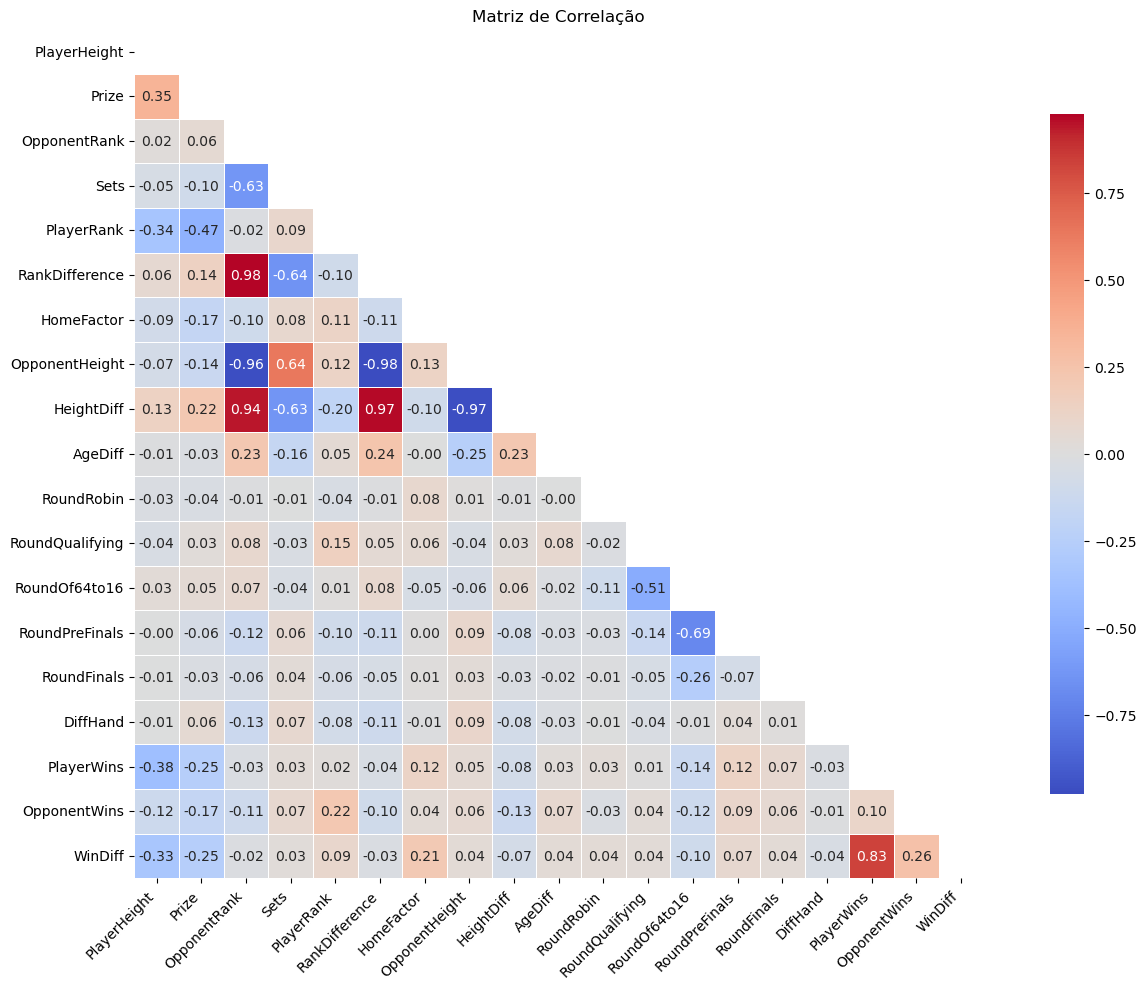

In [116]:
# Matriz de correlação
corr = df_japan.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 10})

plt.title("Matriz de Correlação")
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

### **Multicolinearidade**

Durante a análise de multicolinearidade com o VIF (Variance Inflation Factor), observámos que as variáveis binárias associadas ao tipo de ronda apresentavam valores extremamente elevados, o que é típico quando todas as categorias dummies de uma variável categórica são incluídas em simultâneo.  \
\
Em particular, a variável RoundOf64to16 revelou o maior VIF de todos os preditores (VIF ≈ 2344), evidenciando uma colinearidade quase perfeita com as restantes variáveis de ronda. Por essa razão, optou-se por removê-la, mantendo as demais categorias (RoundQualifying, RoundPreFinals, RoundFinals e RoundRobin).

As variáveis WinDiff e PlayerWins apresentam VIFs moderadamente elevados (3.69 e 3.54, respetivamente), e uma correlação muito forte entre si (ρ = 0.83).
Além disso, a variável WinDiff é derivada diretamente de outras duas variáveis presentes no modelo:  
  
WinDiff = ∣PlayerWins−OpponentWins∣  
  
Ou seja, ela não contém informação nova, mas apenas combina dados que já estão no modelo. A presença simultânea de WinDiff, PlayerWins e OpponentWins cria redundância, o que pode afetar a estabilidade dos coeficientes na modelação

In [117]:
features = [
    'AgeDiff','RoundOf64to16', 'DiffHand', 'WinDiff',
    'PlayerWins', 'OpponentWins',
    'RoundRobin', 'RoundQualifying',
    'RoundPreFinals', 'RoundFinals', 'Prize', 'HomeFactor', 'RankDifference'
]

# Forçar o tipo da variável como float e remover NaNs
X = df_japan[features].astype(float).fillna(0)
X = add_constant(X)

# Calcular VIF
vif = pd.DataFrame()
vif["Variável"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

           Variável           VIF
0             const  11612.141232
1           AgeDiff      1.078222
2     RoundOf64to16   2344.529438
3          DiffHand      1.020649
4           WinDiff      3.868673
5        PlayerWins      3.631189
6      OpponentWins      1.188619
7        RoundRobin     50.803230
8   RoundQualifying    965.214872
9    RoundPreFinals   1548.948630
10      RoundFinals    299.948920
11            Prize      1.139881
12       HomeFactor      1.104017
13   RankDifference      1.133439


### **Visualização de Dados de Interesse**

Nesta secção analisamos graficamente a variável alvo `Sets` e a sua relação com algumas variáveis explicativas, de forma a identificar padrões ou assimetrias relevantes para a modelação.

##### **Distribuição da variável target (Sets)**

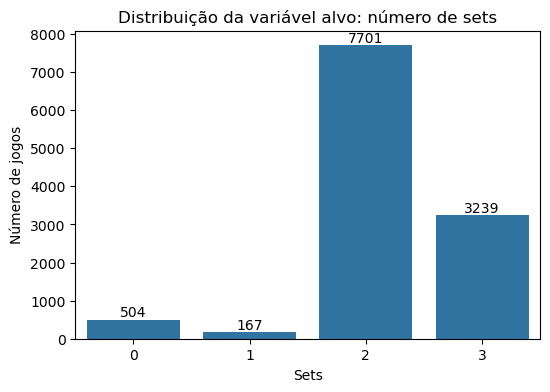

In [118]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df_japan, x='Sets')
plt.title("Distribuição da variável alvo: número de sets")
plt.xlabel("Sets")
plt.ylabel("Número de jogos")

# Adicionar valores absolutos 
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',  
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=10)
plt.show()

##### **Distribuição dos Sets por tipo de Ronda - Gráfico de colunas empilhadas**

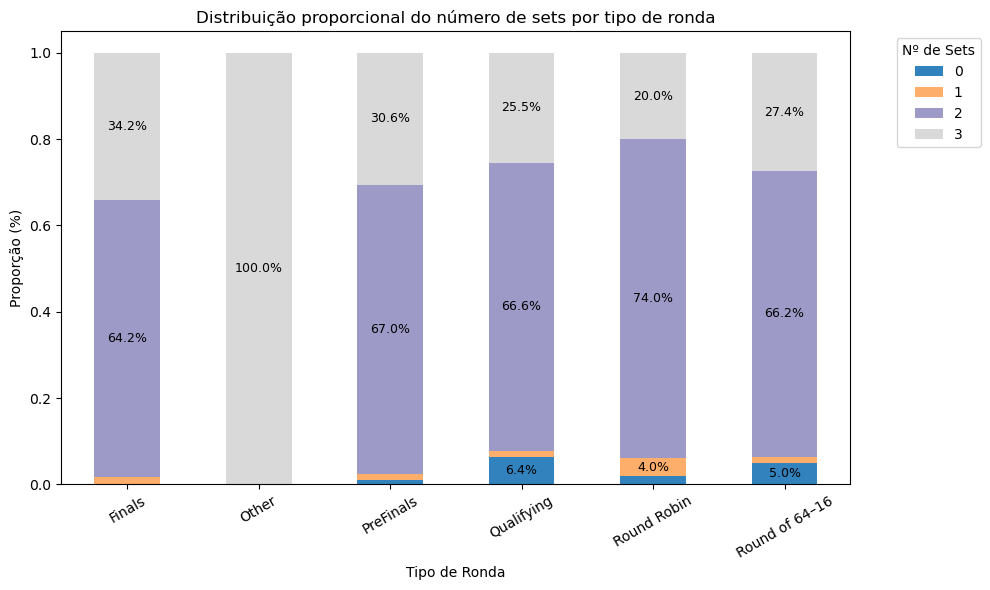

In [119]:
# Criar coluna RoundType
def classify_round(row):
    if row['RoundFinals']:
        return 'Finals'
    elif row['RoundPreFinals']:
        return 'PreFinals'
    elif row['RoundOf64to16']:
        return 'Round of 64–16'
    elif row['RoundQualifying']:
        return 'Qualifying'
    elif row['RoundRobin']:
        return 'Round Robin'
    else:
        return 'Other'

df_japan['RoundType'] = df_japan.apply(classify_round, axis=1)

# Agrupar por RoundType e Sets
grouped = df_japan.groupby(['RoundType', 'Sets']).size().reset_index(name='Count')

# Calcular proporção por RoundType
total_per_round = grouped.groupby('RoundType')['Count'].transform('sum')
grouped['Proportion'] = grouped['Count'] / total_per_round

pivot = grouped.pivot(index='RoundType', columns='Sets', values='Proportion').fillna(0)

# Gráfico de barras empilhadas
pivot = pivot[[0, 1 , 2, 3]] if all(x in pivot.columns for x in [0, 1, 2, 3]) else pivot  # garantir ordem
ax = pivot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20c')
plt.title('Distribuição proporcional do número de sets por tipo de ronda')
plt.ylabel('Proporção (%)')
plt.xlabel('Tipo de Ronda')
plt.legend(title='Nº de Sets', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()

# Percentagens
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x = p.get_x()
    y = p.get_y()
    if height > 0.02:  
        ax.text(x + width / 2, y + height / 2,
                f'{height*100:.1f}%',
                ha='center', va='center', fontsize=9, color='black')
plt.show()

##### **Boxplot para diferença de ranks (sets 1, 2 e 3)**

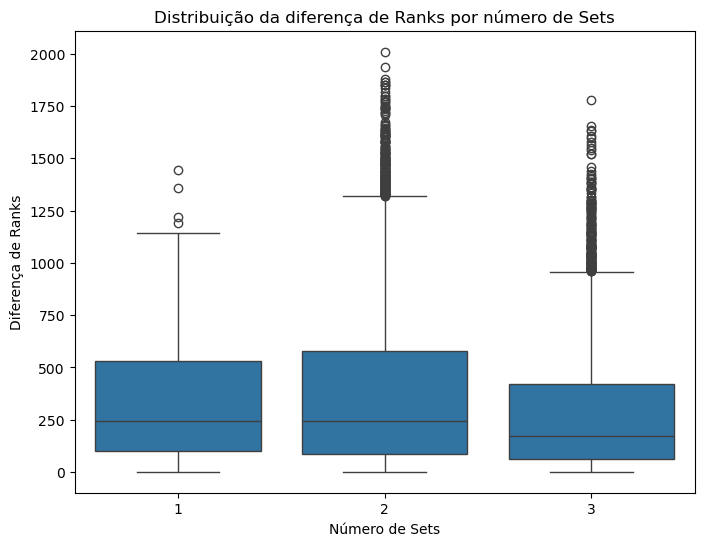

In [120]:
# Filtrar só os sets 1, 2 e 3
df_filtered = df_japan[df_japan['Sets'].isin([1, 2, 3])]

plt.figure(figsize=(8, 6))
sns.boxplot(x='Sets', y='RankDifference', data=df_filtered)
plt.title('Distribuição da diferença de Ranks por número de Sets')
plt.xlabel('Número de Sets')
plt.ylabel('Diferença de Ranks')
plt.show()

##### **Boxplot para diferença de alturas**

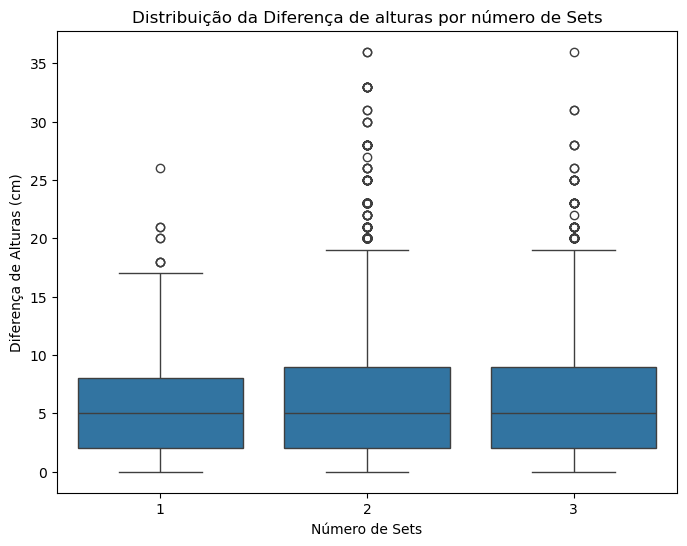

In [121]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Sets', y='HeightDiff', data=df_filtered)
plt.title('Distribuição da Diferença de alturas por número de Sets')
plt.xlabel('Número de Sets')
plt.ylabel('Diferença de Alturas (cm)')
plt.show()

##### **Boxplot para diferença de idades**

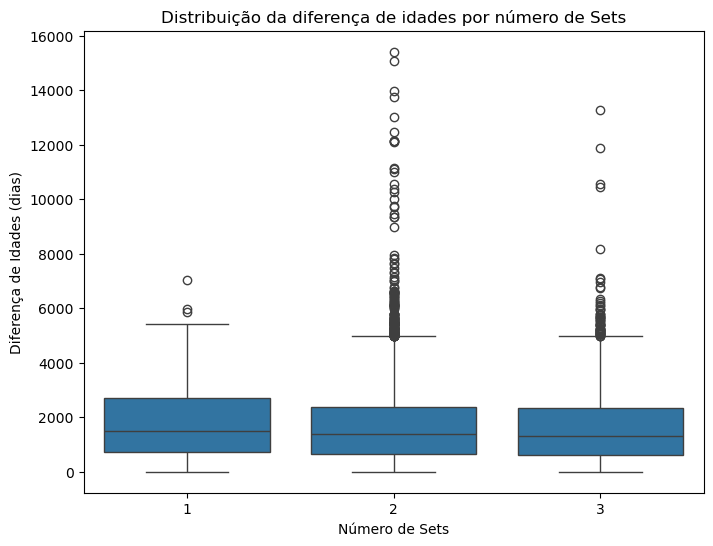

In [122]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Sets', y='AgeDiff', data=df_filtered)
plt.title('Distribuição da diferença de idades por número de Sets')
plt.xlabel('Número de Sets')
plt.ylabel('Diferença de Idades (dias)')
plt.show()

##### **Distribuição do número de sets por diferença de mão (``DiffHand``) - Gráfico de colunas empilhadas**

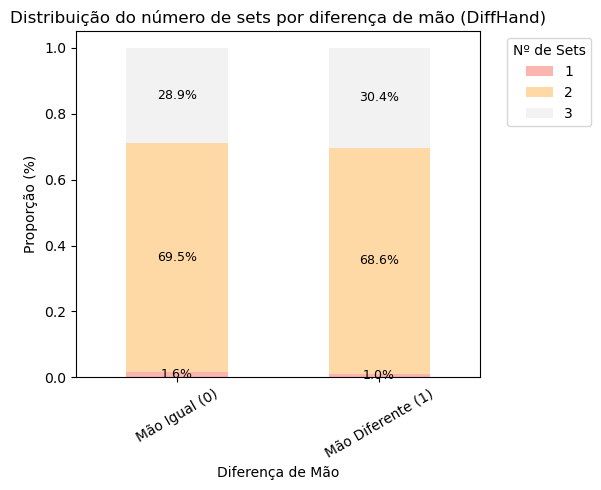

In [123]:
# Agrupar por DiffHand e Sets
grouped = df_japan[df_japan['Sets'].isin([1, 2, 3])].groupby(['DiffHand', 'Sets']).size().reset_index(name='Count')

# Calcular proporções
total_per_hand = grouped.groupby('DiffHand')['Count'].transform('sum')
grouped['Proportion'] = grouped['Count'] / total_per_hand

# Pivot para gráfico
pivot = grouped.pivot(index='DiffHand', columns='Sets', values='Proportion').fillna(0)
pivot = pivot[[1, 2, 3]]  # garantir ordem dos sets

# Gráfico de barras empilhadas
ax = pivot.plot(kind='bar', stacked=True, figsize=(6, 5), colormap='Pastel1')
plt.title('Distribuição do número de sets por diferença de mão (DiffHand)')
plt.ylabel('Proporção (%)')
plt.xlabel('Diferença de Mão')
ax.set_xticklabels(['Mão Igual (0)', 'Mão Diferente (1)'], rotation=30)
plt.legend(title='Nº de Sets', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Percentagens
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x = p.get_x()
    y = p.get_y()
    ax.text(x + width / 2, y + height / 2,
            f'{height*100:.1f}%',
            ha='center', va='center', fontsize=9, color='black')
plt.show()

##### **Distribuição de Sets por ``Ground``**

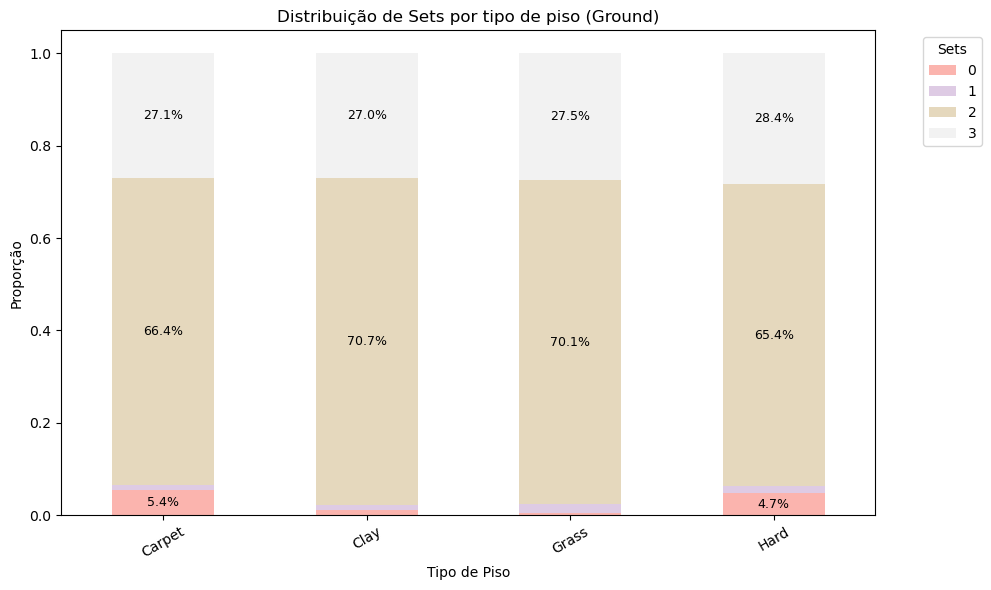

In [124]:
# Gráfico de proporção de Sets por Ground
ct = pd.crosstab(df_japan['Ground'], df_japan['Sets'], normalize='index')

# Gráfico 
ax = ct.plot(kind='bar', stacked=True, colormap='Pastel1', figsize=(10, 6))
plt.title('Distribuição de Sets por tipo de piso (Ground)')
plt.ylabel('Proporção')
plt.xlabel('Tipo de Piso')
plt.legend(title='Sets', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()

# Percentagens
for p in ax.patches:
    height = p.get_height()
    if height > 0.02: 
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + height / 2
        ax.text(x, y, f'{height*100:.1f}%', ha='center', va='center', fontsize=9, color='black')
plt.show()

##### **Distribuição de Sets por ``HomeFactor``**

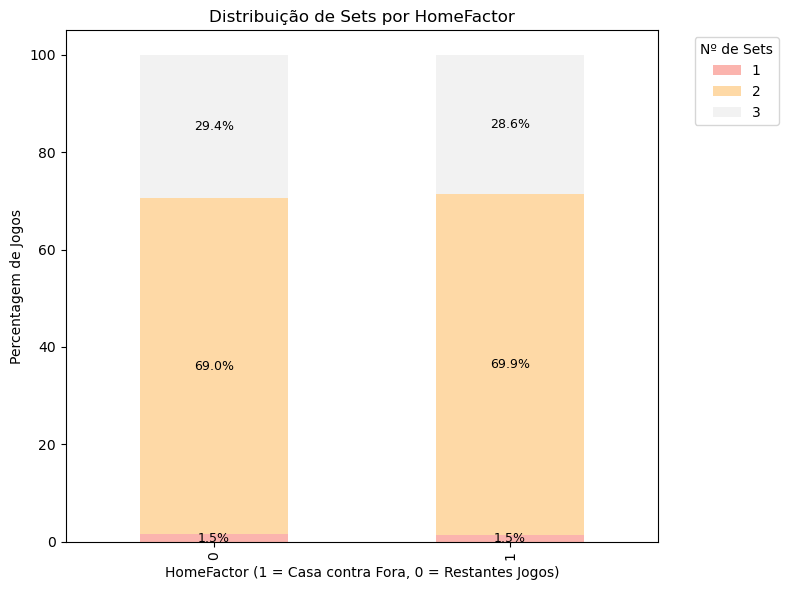

In [125]:
# Variável HomeFactor

# Criar tabela de frequências relativas (percentagens por HomeFactor)
sets_by_home = (
    df_filtered
    .groupby(['HomeFactor', 'Sets'])
    .size()
    .unstack(fill_value=0)
)

# Converter para percentagens por linha
sets_percent = sets_by_home.div(sets_by_home.sum(axis=1), axis=0) * 100

# Plot
sets_percent.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='Pastel1')
for idx, row in sets_percent.iterrows():
    cumulative = 0
    for col in sets_percent.columns:
        value = sets_percent.loc[idx, col]
        if value > 0:
            plt.text(
                x=idx,
                y=cumulative + value / 2,
                s=f"{value:.1f}%",
                ha='center',
                va='center',
                fontsize=9,
                color='black'
            )
        cumulative += value
plt.title('Distribuição de Sets por HomeFactor')
plt.xlabel('HomeFactor (1 = Casa contra Fora, 0 = Restantes Jogos)')
plt.ylabel('Percentagem de Jogos')
plt.legend(title='Nº de Sets', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()